# Assignment 3 - Factors, PCA, Copulas and EVT

__Authors: Team 20__<br>

Andreas: Copulas <br>
Hamza: Copulas <br>
Shubham: Factor Analysis <br>
Milan: EVT <br>
Siddharth: Setup and PCA 



## Setup - Data Loading and Cleaning

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import itertools
import matplotlib.patches as mpatches
import scipy.stats as stats

#  Asset universe: 3 stocks | 2 bond ETFs | 2 indices | 3 commodity ETFs 
assets = {
    # Stocks (large-cap, different sectors)
    "ASML":    "ASML.AS",    # Tech/semis
    "Shell":   "SHELL.AS",    # Energy
    "Walmart": "WMT",     # Consumer staples

    # Bonds (via ETFs — EUR sovereign + corp)
    "USTB":  "BND",    # iShares EUS Treasury Bond ETF
    "EUB": "SYBB.DE",    # State Street Euro Government Bond ETF

    # Indices
    "AEX":     "^AEX",       # Dutch equity index
    "SP500":   "^GSPC",      # US equity index

    # Commodities (via ETFs)
    "Gold":    "GLD",        # Gold
    "Oil":     "USO",        # WTI Crude Oil ETF
    "Iron":  "XME",       # Iron
}

tickers = list(assets.values())
names   = list(assets.keys())

raw = yf.download(tickers, start="2017-01-01", end="2026-04-30",
                  auto_adjust=True, progress=False)["Close"]
print(raw.head())

ticker_to_name = {v: k for k, v in assets.items()}
raw = raw.rename(columns=ticker_to_name)

# Drop any rows with more than 3 NaN (aligns all series to common trading days)
print(f"\nRaw NaN counts:\n{raw.isnull().sum().to_string()}")
prices_clean = raw.copy()
drop_mask = prices_clean.isnull().sum(axis=1) >= 3
prices_clean = prices_clean[~drop_mask]
print(f"\nRows dropped: {drop_mask.sum()}")

# Gap lengths after drop
print("\nNaN counts and max consecutive gap after drop:")
for col in prices_clean.columns:
    s = prices_clean[col]
    total = s.isnull().sum()
    max_gap = max((sum(1 for _ in g) for v, g in itertools.groupby(s.isnull()) if v), default=0)
    print(f"  {col:12s}  nans: {total:3d}  max_gap: {max_gap}")

prices_clean = prices_clean.ffill()

# Log returns
returns = np.log(prices_clean / prices_clean.shift(1)).dropna()

desc = pd.DataFrame({
    'Mean':     returns.mean() * 100,
    'Std':      returns.std()  * 100,
    'Skew':     returns.skew(),
    'Kurt':     returns.kurt(),   # excess kurtosis
    'T':        returns.count().astype(int)
}).round(4)

order = ['ASML','Shell','Walmart','USTB','EUB','AEX','SP500','Gold','Oil','Iron']
print(desc.loc[order].to_latex(float_format='%.4f'))

Ticker        ASML.AS        BND         GLD   SHELL.AS    SYBB.DE        USO  \
Date                                                                            
2017-01-02  97.624046        NaN         NaN  16.159504  57.799671        NaN   
2017-01-03  97.213676  61.247482  110.470001  16.353640  57.375484  91.519997   
2017-01-04  95.891350  61.292908  110.860001  16.433762  57.255600  92.639999   
2017-01-05  96.119331  61.603760  112.580002  16.350563  57.117290  93.599998   
2017-01-06  96.119331  61.361153  111.750000  16.285851  57.052738  93.440002   

Ticker            WMT        XME        ^AEX        ^GSPC  
Date                                                       
2017-01-02        NaN        NaN  486.369995          NaN  
2017-01-03  19.551615  27.618254  487.989990  2257.830078  
2017-01-04  19.665525  28.630959  487.579987  2270.750000  
2017-01-05  19.708233  29.012928  486.929993  2269.000000  
2017-01-06  19.437714  28.248972  487.000000  2276.979980  

Raw NaN cou

__Correlation Heatmap__

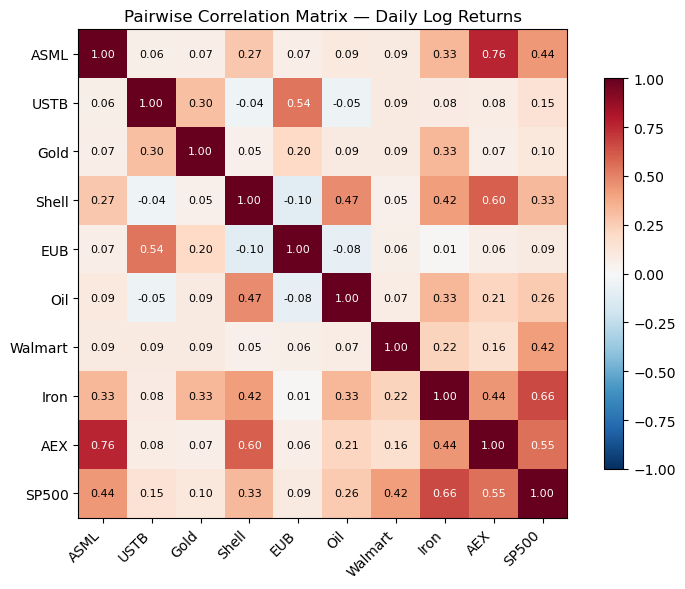

In [2]:

corr = returns.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set(xticks=range(len(corr)), xticklabels=corr.columns,
       yticks=range(len(corr)), yticklabels=corr.columns,
       title="Pairwise Correlation Matrix — Daily Log Returns")
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center",
                fontsize=8, color="white" if abs(corr.iloc[i,j]) > 0.5 else "black")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


__Annualised Volatility__

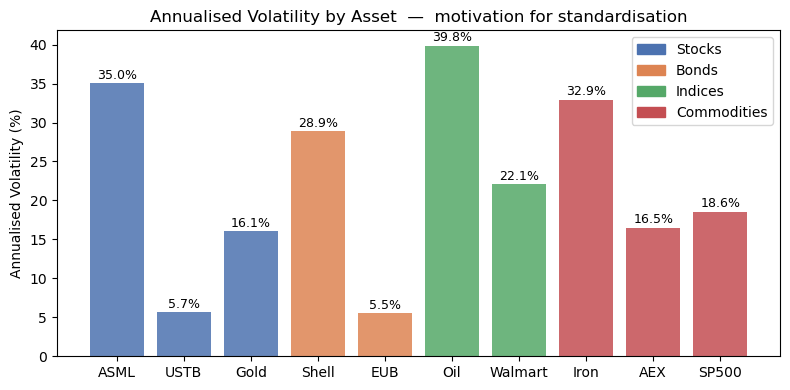

In [3]:
ann_vol = returns.std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#4C72B0"]*3 + ["#DD8452"]*2 + ["#55A868"]*2 + ["#C44E52"]*3
bars = ax.bar(ann_vol.index, ann_vol.values * 100, color=colors, alpha=0.85)
for bar, val in zip(bars, ann_vol.values * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set(ylabel="Annualised Volatility (%)",
       title="Annualised Volatility by Asset  —  motivation for standardisation")

# Asset class legend
from matplotlib.patches import Patch
legend = [Patch(color="#4C72B0", label="Stocks"),
          Patch(color="#DD8452", label="Bonds"),
          Patch(color="#55A868", label="Indices"),
          Patch(color="#C44E52", label="Commodities")]
ax.legend(handles=legend, loc="upper right")
plt.tight_layout()
plt.show()

__Covariance vs Correlation__

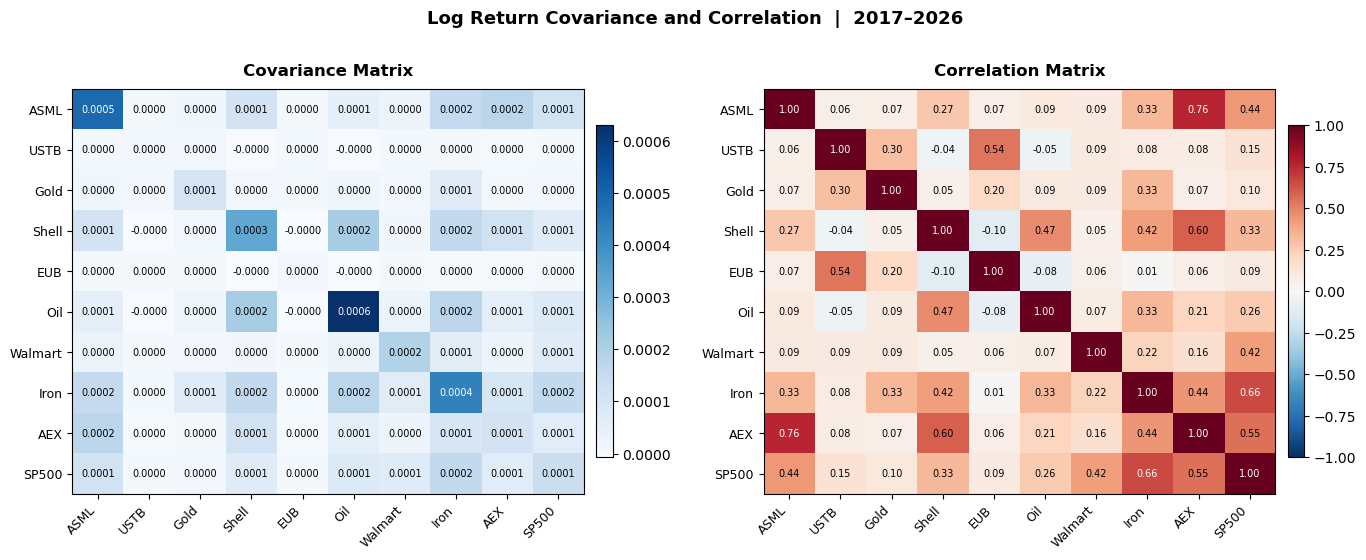

In [4]:
asset_names = returns.columns.tolist()
cov_matrix  = returns.cov()
corr_matrix = returns.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
plt.subplots_adjust(wspace=0.08)

def draw_heatmap(ax, mat, title, fmt, vmin, vmax, cmap):
    im = ax.imshow(mat.values, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(asset_names)))
    ax.set_xticklabels(asset_names, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(asset_names)))
    ax.set_yticklabels(asset_names, fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    for i in range(len(asset_names)):
        for j in range(len(asset_names)):
            val = mat.values[i, j]
            txt_col = 'white' if abs(val) > abs(vmax) * 0.65 else 'black'
            ax.text(j, i, fmt.format(val), ha='center', va='center', fontsize=7, color=txt_col)
    plt.colorbar(im, ax=ax, shrink=0.82, pad=0.02)

draw_heatmap(axes[0], cov_matrix,  'Covariance Matrix',  '{:.4f}',
             vmin=cov_matrix.values.min(), vmax=cov_matrix.values.max(), cmap='Blues')
draw_heatmap(axes[1], corr_matrix, 'Correlation Matrix', '{:.2f}',
             vmin=-1, vmax=1, cmap='RdBu_r')

plt.suptitle('Log Return Covariance and Correlation  |  2017–2026',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

__Cumulative Returns__

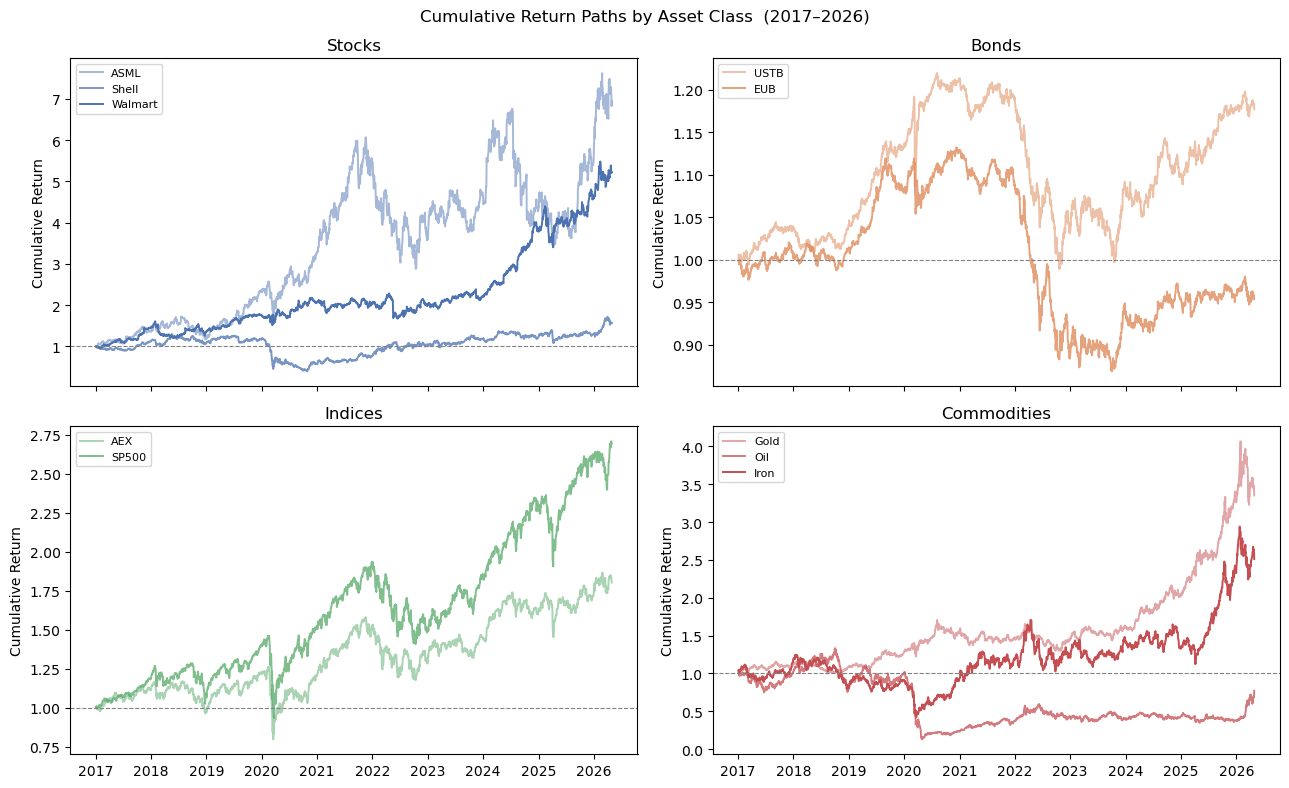

In [5]:
cum_returns = (1 + returns).cumprod()

asset_classes = {
    "Stocks":      ["ASML", "Shell", "Walmart"],
    "Bonds":       ["USTB", "EUB"],
    "Indices":     ["AEX", "SP500"],
    "Commodities": ["Gold", "Oil", "Iron"],
}
colors_map = {"Stocks": "#4C72B0", "Bonds": "#DD8452",
              "Indices": "#55A868", "Commodities": "#C44E52"}

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, (cls, members) in zip(axes.flat, asset_classes.items()):
    for asset in members:
        ax.plot(cum_returns.index, cum_returns[asset],
                label=asset, color=colors_map[cls],
                alpha=0.5 + 0.25 * members.index(asset),
                linewidth=1.4)
    ax.set(title=cls, ylabel="Cumulative Return")
    ax.legend(fontsize=8)
    ax.axhline(1, color="gray", linestyle="--", linewidth=0.8)

plt.suptitle("Cumulative Return Paths by Asset Class  (2017–2026)", fontsize=12)
plt.tight_layout()
plt.show()

__Asset Correlations__

In [6]:
print("  WITHIN-GROUP average correlations")
print("─" * 52)
for cls, members in asset_classes.items():
    if len(members) > 1:
        pairs = [(i, j) for i in members for j in members if i < j]
        avg_corr = np.mean([corr.loc[i, j] for i, j in pairs])
        print(f"  {cls:<14}  avg ρ = {avg_corr:.3f}")

print()
print("  CROSS-GROUP average correlations")
print("─" * 52)
class_list = list(asset_classes.keys())
for i in range(len(class_list)):
    for j in range(i+1, len(class_list)):
        g1, g2 = class_list[i], class_list[j]
        m1, m2 = asset_classes[g1], asset_classes[g2]
        avg_cross = np.mean([corr.loc[a, b] for a in m1 for b in m2])
        print(f"  {g1:<12} × {g2:<12}  avg ρ = {avg_cross:.3f}")

  WITHIN-GROUP average correlations
────────────────────────────────────────────────────
  Stocks          avg ρ = 0.139
  Bonds           avg ρ = 0.535
  Indices         avg ρ = 0.552
  Commodities     avg ρ = 0.251

  CROSS-GROUP average correlations
────────────────────────────────────────────────────
  Stocks       × Bonds         avg ρ = 0.023
  Stocks       × Indices       avg ρ = 0.450
  Stocks       × Commodities   avg ρ = 0.203
  Bonds        × Indices       avg ρ = 0.094
  Bonds        × Commodities   avg ρ = 0.078
  Indices      × Commodities   avg ρ = 0.291


## PCA

Eigenvalues (sorted): [3.2655 1.7618 1.1543 1.0677 0.8273 0.5853 0.5086 0.446  0.2454 0.1339]


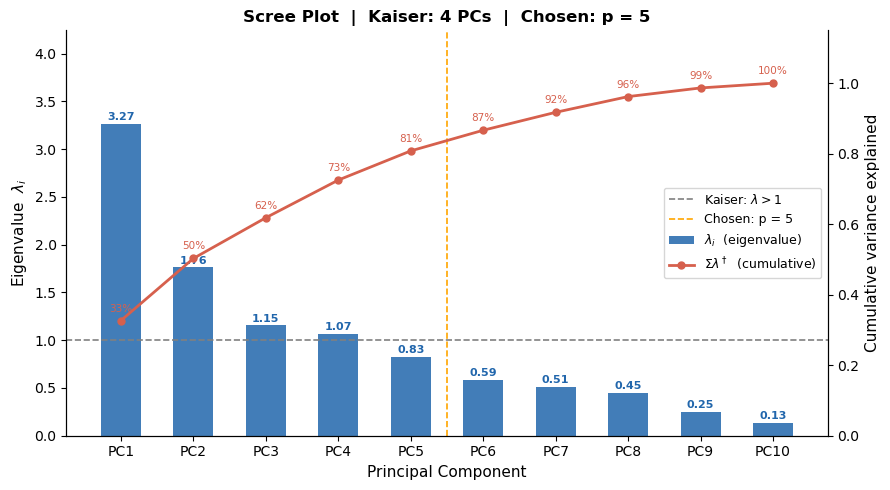

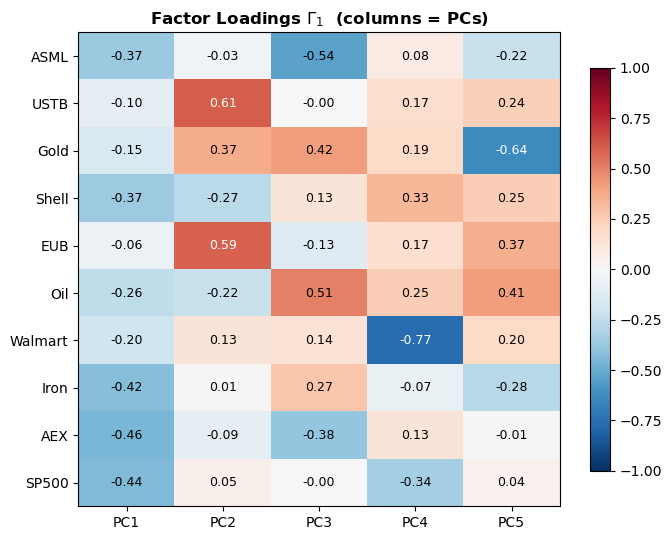

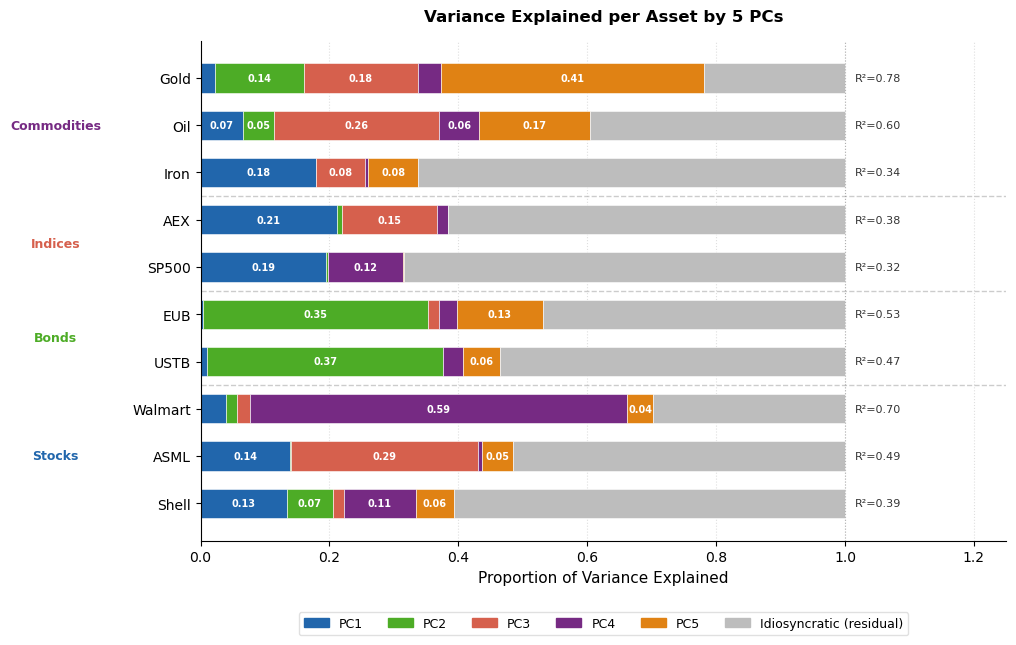

In [7]:
# Standardise returns
X_tilde = (returns - returns.mean()) / returns.std()

# Correlation matrix
n = len(X_tilde)
A = (X_tilde.T @ X_tilde) / n

# Eigendecomposition, sorted largest to smallest
eigenvalues_raw, eigenvectors_raw = np.linalg.eig(A)
order        = np.argsort(eigenvalues_raw)[::-1]
eigenvalues  = eigenvalues_raw[order].real
eigenvectors = eigenvectors_raw[:, order].real
print("Eigenvalues (sorted):", np.round(eigenvalues, 4))

# Normalise eigenvectors to unit length
eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)

# Variance explained
d                = len(eigenvalues)
var_explained    = eigenvalues / eigenvalues.sum()
cumvar_explained = np.cumsum(var_explained)

n_kaiser = int((eigenvalues > 1).sum())
n_90pct  = int(np.searchsorted(cumvar_explained, 0.90) + 1)
p        = 5

# Scree plot
all_labels = [f'PC{i+1}' for i in range(len(eigenvalues))]

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

bars = ax1.bar(all_labels, eigenvalues, color='#2166AC', alpha=0.85,
               width=0.55, label=r'$\lambda_i$  (eigenvalue)')
for bar, v in zip(bars, eigenvalues):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f'{v:.2f}', ha='center', va='bottom', fontsize=8,
             color='#2166AC', fontweight='bold')

ax2.plot(all_labels, cumvar_explained, color='#D6604D', marker='o',
         linewidth=2, markersize=5, label=r'$\Sigma\lambda^\dagger$  (cumulative)')
for i, cv in enumerate(cumvar_explained):
    ax2.text(i, cv + 0.02, f'{cv*100:.0f}%', ha='center', va='bottom',
             fontsize=7.5, color='#D6604D')

ax1.axhline(1.0, color='gray', linestyle='--', linewidth=1.2,
            label='Kaiser: $\\lambda > 1$')
ax1.axvline(p - 0.5, color='orange', linestyle='--', linewidth=1.2,
            label=f'Chosen: p = {p}')

ax1.set_ylabel(r'Eigenvalue  $\lambda_i$', fontsize=11)
ax1.set_xlabel('Principal Component', fontsize=11)
ax2.set_ylabel(r'Cumulative variance explained', fontsize=11)
ax2.set_ylim(0, 1.15)
ax1.set_ylim(0, eigenvalues.max() * 1.3)
ax1.set_title(f'Scree Plot  |  Kaiser: {n_kaiser} PCs  |  Chosen: p = {p}',
              fontsize=12, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='center right')
ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)
plt.tight_layout()
plt.show()

# Factor loadings and scores
Gamma_1 = eigenvectors[:, :p]
F_hat   = pd.DataFrame(
    X_tilde.values @ Gamma_1,
    index=returns.index,
    columns=[f'PC{i+1}' for i in range(p)]
)

loadings = pd.DataFrame(Gamma_1, index=asset_names,
                        columns=[f'PC{i+1}' for i in range(p)])

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(loadings.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(p))
ax.set_xticklabels(loadings.columns, fontsize=10)
ax.set_yticks(range(len(asset_names)))
ax.set_yticklabels(asset_names, fontsize=10)
ax.set_title(r'Factor Loadings $\Gamma_1$  (columns = PCs)',
             fontsize=12, fontweight='bold')
for i in range(len(asset_names)):
    for j in range(p):
        val = loadings.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(val) > 0.55 else 'black')
plt.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()
plt.show()

# Variance decomposition
Sigma_factor = Gamma_1 @ Gamma_1.T
Upsilon      = A - Sigma_factor
R2_per_asset = pd.Series(np.diag(Sigma_factor) / np.diag(A), index=asset_names)

# R² stacked bar chart
R2_contributions = pd.DataFrame(
    Gamma_1 ** 2 / np.diag(A)[:, None],
    index=asset_names,
    columns=[f'PC{j+1}' for j in range(p)]
)
R2_total = R2_contributions.sum(axis=1)

asset_types = {
    'Stocks':      ['ASML', 'Shell', 'Walmart'],
    'Bonds':       ['USTB', 'EUB'],
    'Indices':     ['AEX', 'SP500'],
    'Commodities': ['Gold', 'Oil', 'Iron'],
}
ordered_assets, group_boundaries = [], []
idx = 0
for label, members in asset_types.items():
    sorted_m = R2_total[members].sort_values(ascending=True).index.tolist()
    ordered_assets.extend(sorted_m)
    group_boundaries.append((idx, idx + len(sorted_m) - 1, label))
    idx += len(sorted_m)

R2_plot = R2_contributions.loc[ordered_assets]
R2_idio = 1.0 - R2_plot.sum(axis=1)

pc_colors   = ['#2166AC', '#4DAC26', '#D6604D', '#762A83', '#E08214']
type_colors = {'Stocks':'#2166AC', 'Bonds':'#4DAC26',
               'Indices':'#D6604D', 'Commodities':'#762A83'}

fig, ax = plt.subplots(figsize=(10, 6.5))
plt.subplots_adjust(left=0.22, right=0.88, top=0.88, bottom=0.18)

y_pos = np.arange(len(ordered_assets))
left  = np.zeros(len(ordered_assets))

for j in range(p):
    vals = R2_plot[f'PC{j+1}'].values
    ax.barh(y_pos, vals, left=left, height=0.62,
            color=pc_colors[j], label=f'PC{j+1}',
            edgecolor='white', linewidth=0.4)
    for i, (v, l) in enumerate(zip(vals, left)):
        if v > 0.04:
            ax.text(l + v/2, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold')
    left += vals

ax.barh(y_pos, R2_idio.values, left=left, height=0.62,
        color='#BDBDBD', label='Idiosyncratic (residual)',
        edgecolor='white', linewidth=0.4)
for i, (tot, l) in enumerate(zip(R2_plot.sum(axis=1).values, left)):
    ax.text(l + R2_idio.values[i] + 0.015, i,
            f'R²={tot:.2f}', va='center', fontsize=8, color='#333333')

ax.set_yticks(y_pos)
ax.set_yticklabels(ordered_assets, fontsize=10)
ax.set_xlim(0, 1.25)
ax.set_xlabel('Proportion of Variance Explained', fontsize=11)
ax.set_title(f'Variance Explained per Asset by {p} PCs',
             fontsize=12, fontweight='bold', pad=14)
ax.spines[['top', 'right']].set_visible(False)
ax.axvline(1.0, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
ax.xaxis.grid(True, linestyle=':', alpha=0.4)
ax.set_axisbelow(True)

for (start, end, label) in group_boundaries:
    mid_y = (start + end) / 2.0
    if start > 0:
        ax.axhline(start - 0.5, color='#CCCCCC', linewidth=1.0, linestyle='--', zorder=0)
    ax.annotate(label,
                xy=(0, mid_y), xycoords=('axes fraction', 'data'),
                xytext=(-0.18, mid_y), textcoords=('axes fraction', 'data'),
                ha='center', va='center', fontsize=9, fontweight='bold',
                color=type_colors[label], annotation_clip=False)

legend_handles = [mpatches.Patch(color=pc_colors[j], label=f'PC{j+1}') for j in range(p)]
legend_handles.append(mpatches.Patch(color='#BDBDBD', label='Idiosyncratic (residual)'))
ax.legend(handles=legend_handles, loc='upper center',
          bbox_to_anchor=(0.5, -0.13), ncol=6,
          fontsize=9, framealpha=0.9, edgecolor='#DDDDDD')

plt.tight_layout()
plt.show()

## Factor Analysis

Instead of using purely statistical PCA factors, we use simple **fundamental factor-mimicking portfolios**:

- **Equity factor:** average return of ASML, Shell, Walmart, AEX and S&P 500.
- **Bond factor:** average return of USTB and EUB.
- **Commodity factor:** average return of Gold, Oil and Iron.

For each asset, the factor portfolio is built **excluding that asset itself** when it belongs to the same group. This keeps the regression from becoming mechanical. Each asset return is then regressed on the three standardised factors:

$$
\tilde r_{i,t}=\alpha_i+\beta_{i,Eq}F_{Eq,t}+\beta_{i,Bond}F_{Bond,t}+\beta_{i,Com}F_{Com,t}+\epsilon_{i,t}.
$$

We compare this interpretable factor model with the PCA model using loadings, residual correlations and asset-level $R^2$.

Fundamental factor loadings, using standardised returns
         Equity   Bond  Commodity
ASML      0.532  0.049     -0.061
Shell     0.229 -0.133      0.427
Walmart   0.140  0.073      0.103
USTB      0.023  0.534      0.070
EUB       0.025  0.538     -0.052
AEX       0.868  0.026     -0.089
SP500     0.455  0.098      0.301
Gold     -0.069  0.300      0.286
Oil       0.228 -0.123      0.206
Iron      0.487  0.010      0.259

Asset-level R² from the fundamental factor model
         FA_R2  Idiosyncratic
AEX      0.684          0.316
SP500    0.442          0.558
Iron     0.388          0.612
Shell    0.320          0.680
USTB     0.294          0.706
EUB      0.288          0.712
ASML     0.255          0.745
Gold     0.149          0.851
Oil      0.144          0.856
Walmart  0.052          0.948


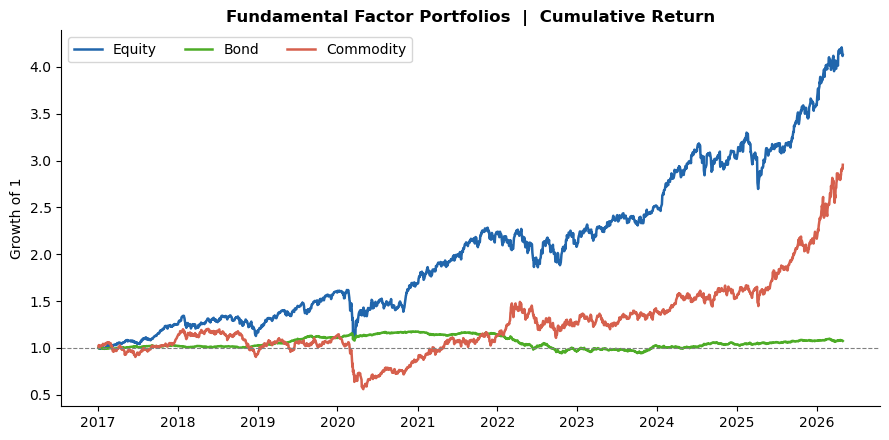

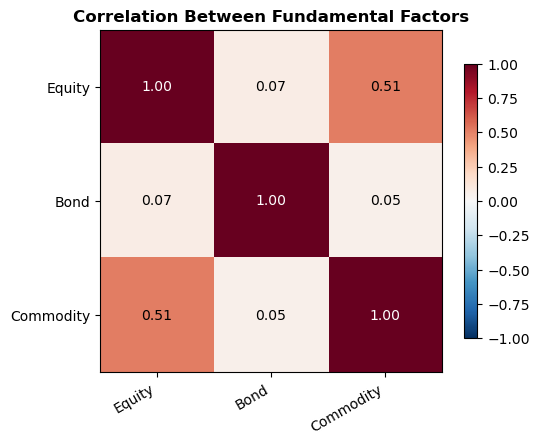

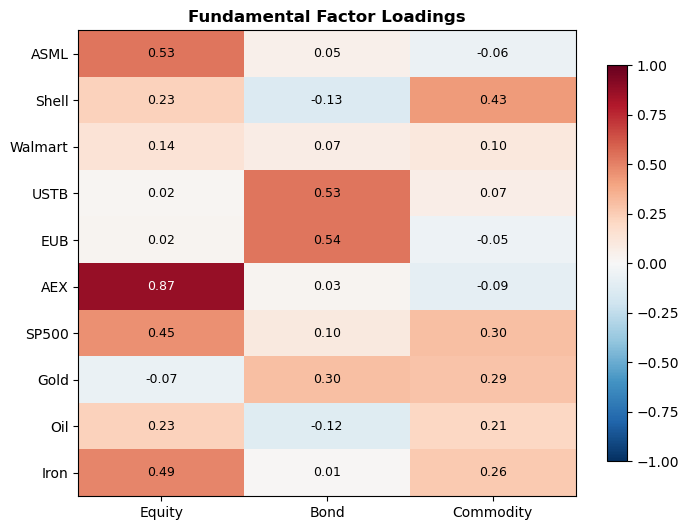

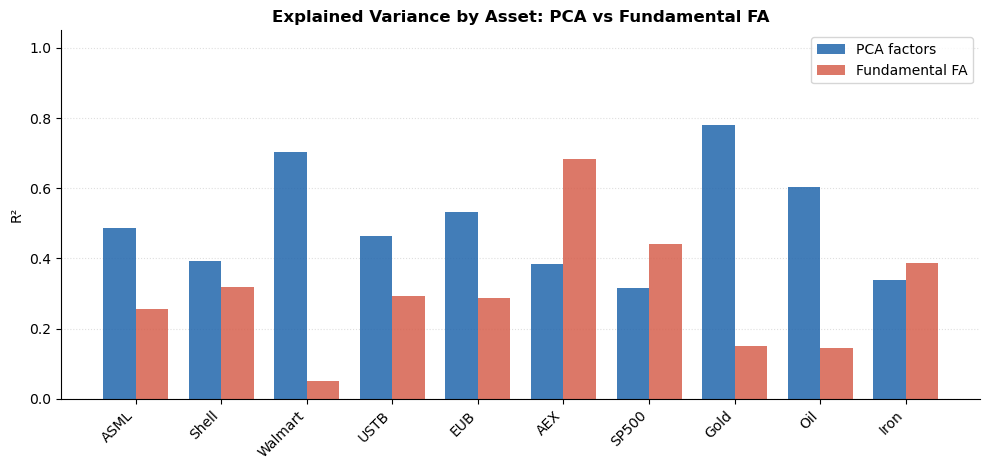

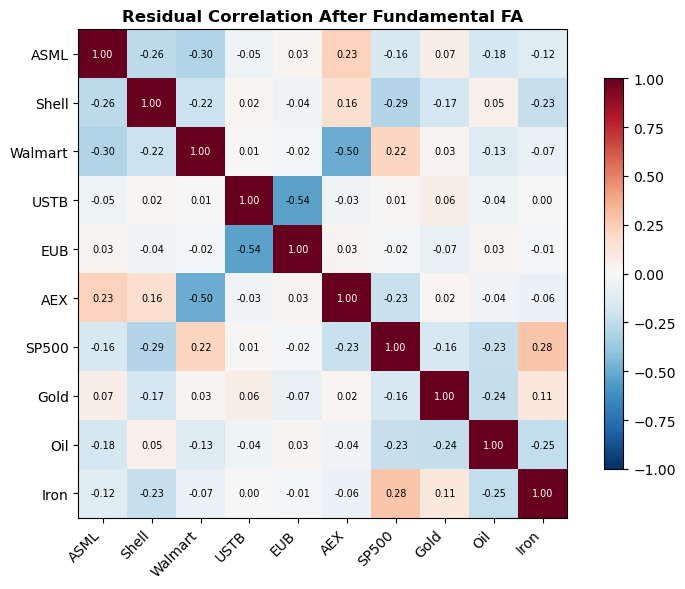


Model comparison
Mean asset R², PCA model:        0.500
Mean asset R², fundamental FA:   0.302
Average |correlation| before FA: 0.224
Average |correlation| after FA:  0.133

Interpretation: PCA explains more variance because its factors are chosen mechanically to maximise variance.
The fundamental FA is easier to name and discuss, but usually leaves more residual dependence.


In [8]:
# Fundamental Factor Analysis (non-PCA)
# ------------------------------------------------------------
# The factors are interpretable portfolio returns rather than eigenvectors.
# For each target asset, the target is excluded from its own group factor.

fa_groups = {
    "Equity": ["ASML", "Shell", "Walmart", "AEX", "SP500"],
    "Bond": ["USTB", "EUB"],
    "Commodity": ["Gold", "Oil", "Iron"],
}
fa_factor_names = list(fa_groups.keys())

fa_asset_order = ["ASML", "Shell", "Walmart", "USTB", "EUB", "AEX", "SP500", "Gold", "Oil", "Iron"]
fa_asset_order = [asset for asset in fa_asset_order if asset in returns.columns]
R = returns[fa_asset_order].copy()
asset_names = R.columns.tolist()

def zscore(df):
    return (df - df.mean()) / df.std()

def factor_panel_for_target(target):
    panel = pd.DataFrame(index=R.index)
    for name, members in fa_groups.items():
        usable = [m for m in members if m in R.columns and m != target]
        panel[name] = R[usable].mean(axis=1)
    return panel

# Representative factors, used only for visualising the factor behaviour/correlation.
fa_factors = pd.DataFrame({
    name: R[[m for m in members if m in R.columns]].mean(axis=1)
    for name, members in fa_groups.items()
}, index=R.index)
fa_factors_z = zscore(fa_factors)

# OLS asset-by-asset: standardised returns on standardised fundamental factors.
fa_loadings = pd.DataFrame(index=asset_names, columns=fa_factor_names, dtype=float)
fa_r2 = pd.Series(index=asset_names, dtype=float, name="FA_R2")
fa_residuals = pd.DataFrame(index=R.index, columns=asset_names, dtype=float)

for asset in asset_names:
    y = zscore(R[[asset]])[asset].values
    X = zscore(factor_panel_for_target(asset)).values
    X_design = np.column_stack([np.ones(len(X)), X])
    coef = np.linalg.lstsq(X_design, y, rcond=None)[0]
    fitted = X_design @ coef
    resid = y - fitted

    fa_loadings.loc[asset] = coef[1:]
    fa_residuals[asset] = resid
    fa_r2.loc[asset] = 1 - np.sum(resid**2) / np.sum((y - y.mean())**2)

fa_idio = 1 - fa_r2
fa_summary = pd.DataFrame({
    "FA_R2": fa_r2,
    "Idiosyncratic": fa_idio,
}).sort_values("FA_R2", ascending=False)

print("Fundamental factor loadings, using standardised returns")
print(fa_loadings.round(3).to_string())
print("\nAsset-level R² from the fundamental factor model")
print(fa_summary.round(3).to_string())

# Visual 1: cumulative factor returns
fa_cum = np.exp(fa_factors.cumsum())
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = {"Equity": "#2166AC", "Bond": "#4DAC26", "Commodity": "#D6604D"}
for factor in fa_factor_names:
    ax.plot(fa_cum.index, fa_cum[factor], label=factor, color=colors[factor], linewidth=1.8)
ax.axhline(1, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Fundamental Factor Portfolios  |  Cumulative Return", fontweight="bold")
ax.set_ylabel("Growth of 1")
ax.legend(ncol=3, frameon=True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Visual 2: factor correlations, showing that fundamental factors need not be orthogonal.
fig, ax = plt.subplots(figsize=(5.5, 4.5))
fac_corr = fa_factors.corr()
im = ax.imshow(fac_corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(fa_factor_names)))
ax.set_xticklabels(fa_factor_names, rotation=30, ha="right")
ax.set_yticks(range(len(fa_factor_names)))
ax.set_yticklabels(fa_factor_names)
ax.set_title("Correlation Between Fundamental Factors", fontweight="bold")
for i in range(len(fa_factor_names)):
    for j in range(len(fa_factor_names)):
        val = fac_corr.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="white" if abs(val) > 0.55 else "black")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

# Visual 3: loadings heatmap.
fig, ax = plt.subplots(figsize=(7.2, 5.4))
im = ax.imshow(fa_loadings.values.astype(float), cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(fa_factor_names)))
ax.set_xticklabels(fa_factor_names)
ax.set_yticks(range(len(asset_names)))
ax.set_yticklabels(asset_names)
ax.set_title("Fundamental Factor Loadings", fontweight="bold")
for i in range(len(asset_names)):
    for j in range(len(fa_factor_names)):
        val = fa_loadings.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="white" if abs(val) > 0.55 else "black", fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()
plt.show()

# Visual 4: R² comparison against PCA if PCA results are available.
if "R2_total" not in globals():
    X_tilde_tmp = zscore(R)
    A_tmp = (X_tilde_tmp.T @ X_tilde_tmp) / len(X_tilde_tmp)
    eigvals_tmp, eigvecs_tmp = np.linalg.eig(A_tmp)
    idx_tmp = np.argsort(eigvals_tmp)[::-1]
    eigvecs_tmp = eigvecs_tmp[:, idx_tmp].real
    p_tmp = 5
    Gamma_tmp = eigvecs_tmp[:, :p_tmp]
    R2_total = pd.Series((Gamma_tmp ** 2).sum(axis=1), index=asset_names)

r2_compare = pd.DataFrame({
    "PCA factors": R2_total.reindex(asset_names),
    "Fundamental FA": fa_r2.reindex(asset_names),
})

fig, ax = plt.subplots(figsize=(10, 4.8))
x = np.arange(len(asset_names))
width = 0.38
ax.bar(x - width/2, r2_compare["PCA factors"], width, label="PCA factors", color="#2166AC", alpha=0.85)
ax.bar(x + width/2, r2_compare["Fundamental FA"], width, label="Fundamental FA", color="#D6604D", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(asset_names, rotation=45, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("R²")
ax.set_title("Explained Variance by Asset: PCA vs Fundamental FA", fontweight="bold")
ax.legend()
ax.yaxis.grid(True, linestyle=":", alpha=0.4)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Visual 5: residual dependence after the FA regression.
resid_corr = fa_residuals.corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(resid_corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(asset_names)))
ax.set_xticklabels(asset_names, rotation=45, ha="right")
ax.set_yticks(range(len(asset_names)))
ax.set_yticklabels(asset_names)
ax.set_title("Residual Correlation After Fundamental FA", fontweight="bold")
for i in range(len(asset_names)):
    for j in range(len(asset_names)):
        val = resid_corr.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(val) > 0.55 else "black")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

# Compact interpretation numbers for the report.
orig_avg_abs_corr = R.corr().where(~np.eye(len(asset_names), dtype=bool)).abs().stack().mean()
resid_avg_abs_corr = resid_corr.where(~np.eye(len(asset_names), dtype=bool)).abs().stack().mean()
print("\nModel comparison")
print(f"Mean asset R², PCA model:        {r2_compare['PCA factors'].mean():.3f}")
print(f"Mean asset R², fundamental FA:   {r2_compare['Fundamental FA'].mean():.3f}")
print(f"Average |correlation| before FA: {orig_avg_abs_corr:.3f}")
print(f"Average |correlation| after FA:  {resid_avg_abs_corr:.3f}")
print("\nInterpretation: PCA explains more variance because its factors are chosen mechanically to maximise variance.")
print("The fundamental FA is easier to name and discuss, but usually leaves more residual dependence.")


## Copulas

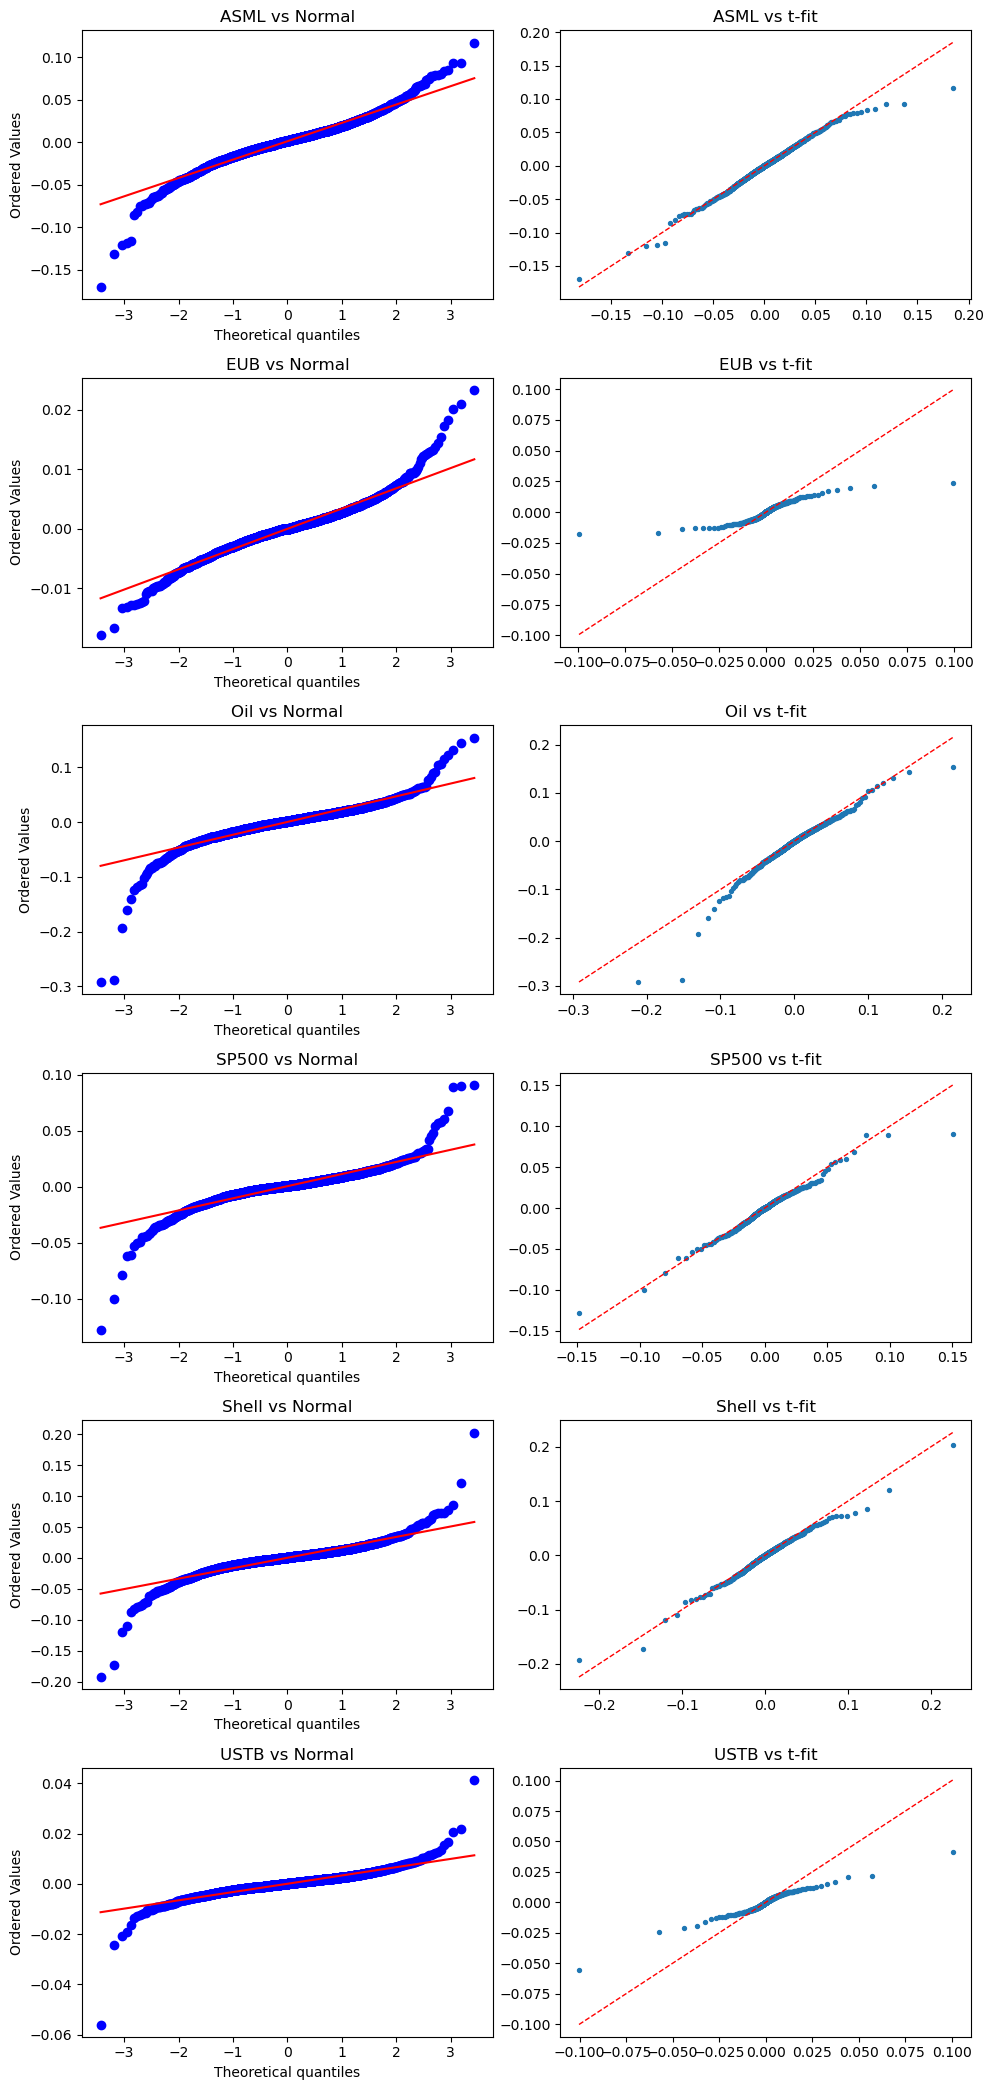

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pairs = [['SP500', 'ASML'], ['Shell', 'EUB'], ['Oil', 'USTB']]
assets = sorted(set([x for pair in pairs for x in pair]))

fig, axes = plt.subplots(len(assets), 2, figsize=(10, 3.5 * len(assets)))

for i, asset in enumerate(assets):
    x = returns[asset].dropna().values

    # Normal QQ
    stats.probplot(x, dist="norm", plot=axes[i, 0])
    axes[i, 0].set_title(f"{asset} vs Normal")

    # Student-t QQ: fit df, loc, scale first
    params_t = stats.t.fit(x)
    dist_t = stats.t(*params_t)

    p = (np.arange(1, len(x)+1) - 0.5) / len(x)
    theo_q = dist_t.ppf(p)
    samp_q = np.sort(x)

    axes[i, 1].scatter(theo_q, samp_q, s=8)
    mn = min(theo_q.min(), samp_q.min())
    mx = max(theo_q.max(), samp_q.max())
    axes[i, 1].plot([mn, mx], [mn, mx], 'r--', lw=1)
    axes[i, 1].set_title(f"{asset} vs t-fit")

plt.tight_layout()
plt.show()

In [10]:
# bonds -> normal distr, rest -> t-distr
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.distributions.copula.api import (
    CopulaDistribution,
    GaussianCopula,
    StudentTCopula
)

pairs = [['SP500', 'ASML'], ['Shell', 'EUB'], ['Oil', 'USTB']]
bond_assets = {'EUB', 'USTB'}

def fit_marginal(x, asset):
    x = pd.Series(x).dropna().values

    if asset in bond_assets:
        params = stats.norm.fit(x)      # loc, scale
        dist = stats.norm(*params)
        family = 'normal'
    else:
        params = stats.t.fit(x)         # df, loc, scale
        dist = stats.t(*params)
        family = 'student_t'

    return {'family': family, 'params': params, 'dist': dist}

results = {}

for a, b in pairs:
    df_pair = returns[[a, b]].dropna()

    fit_a = fit_marginal(df_pair[a], a)
    fit_b = fit_marginal(df_pair[b], b)

    u = fit_a['dist'].cdf(df_pair[a].values)
    v = fit_b['dist'].cdf(df_pair[b].values)

    uv = np.column_stack([u, v])
    uv = np.clip(uv, 1e-6, 1 - 1e-6)

    gauss = GaussianCopula()
    rho_g = gauss.fit_corr_param(uv)
    gauss = GaussianCopula(corr=rho_g)

    t_cop = StudentTCopula(df=5)
    rho_t = t_cop.fit_corr_param(uv)
    t_cop = StudentTCopula(corr=rho_t, df=5)

    joint_gauss = CopulaDistribution(
        copula=gauss,
        marginals=[fit_a['dist'], fit_b['dist']]
    )

    joint_t = CopulaDistribution(
        copula=t_cop,
        marginals=[fit_a['dist'], fit_b['dist']]
    )

    results[(a, b)] = {
        'asset1': a,
        'asset2': b,
        'fit1': fit_a,
        'fit2': fit_b,
        'uv': uv,
        'gaussian': joint_gauss,
        'student_t': joint_t,
        'rho_gaussian': rho_g,
        'rho_t': rho_t
    }


In [11]:
results[('SP500', 'ASML')]

{'asset1': 'SP500',
 'asset2': 'ASML',
 'fit1': {'family': 'student_t',
  'params': (2.609238470395427, 0.0009909502516666489, 0.0064584806358371),
  'dist': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x17d2c4e00>},
 'fit2': {'family': 'student_t',
  'params': (3.740837552774172, 0.0014316909402581723, 0.015550426695074714),
  'dist': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x17d0b4260>},
 'uv': array([[0.73732473, 0.19464309],
        [0.40256785, 0.5226254 ],
        [0.63697745, 0.46568078],
        ...,
        [0.51353114, 0.05885966],
        [0.21877104, 0.0440852 ],
        [0.4226361 , 0.81946177]]),
 'gaussian': <statsmodels.distributions.copula.copulas.CopulaDistribution at 0x17d7dd430>,
 'student_t': <statsmodels.distributions.copula.copulas.CopulaDistribution at 0x17d796f30>,
 'rho_gaussian': 0.49949343690128084,
 'rho_t': 0.49949343690128084}

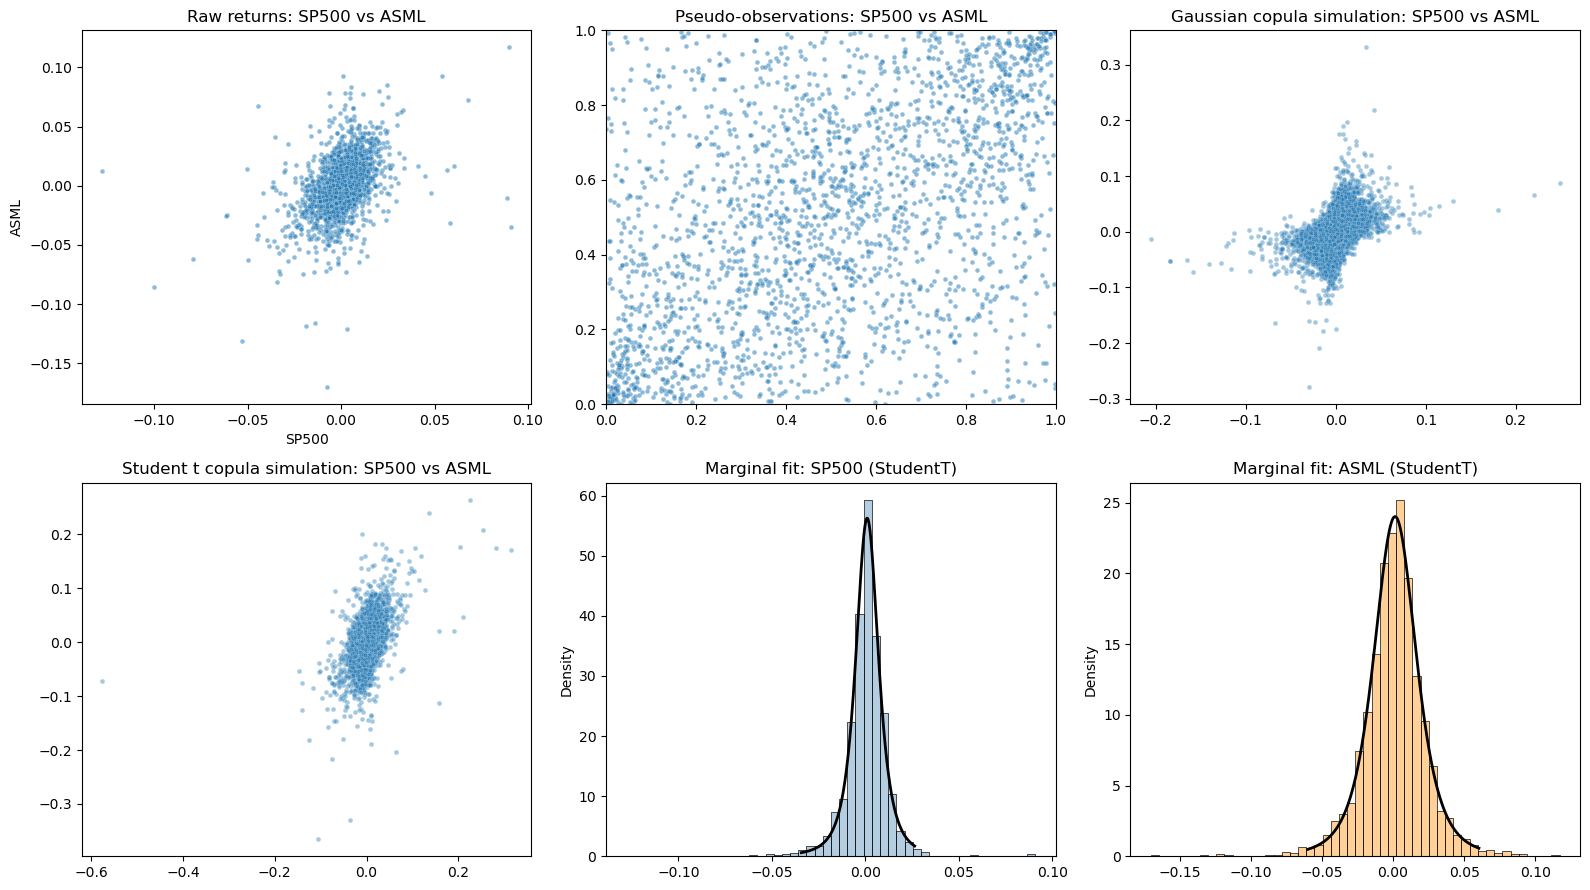

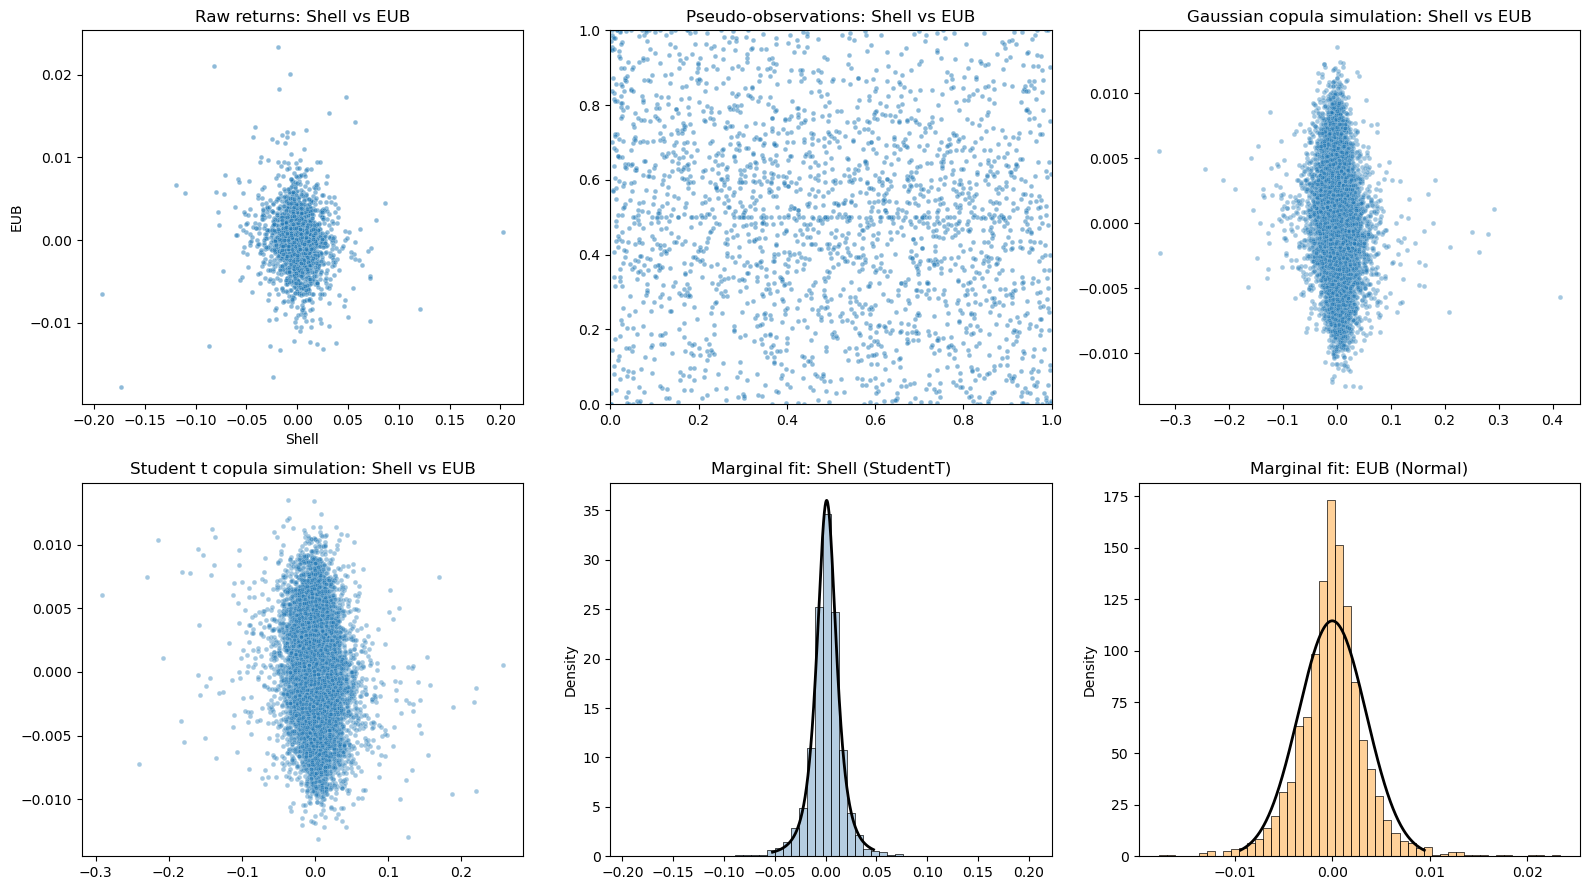

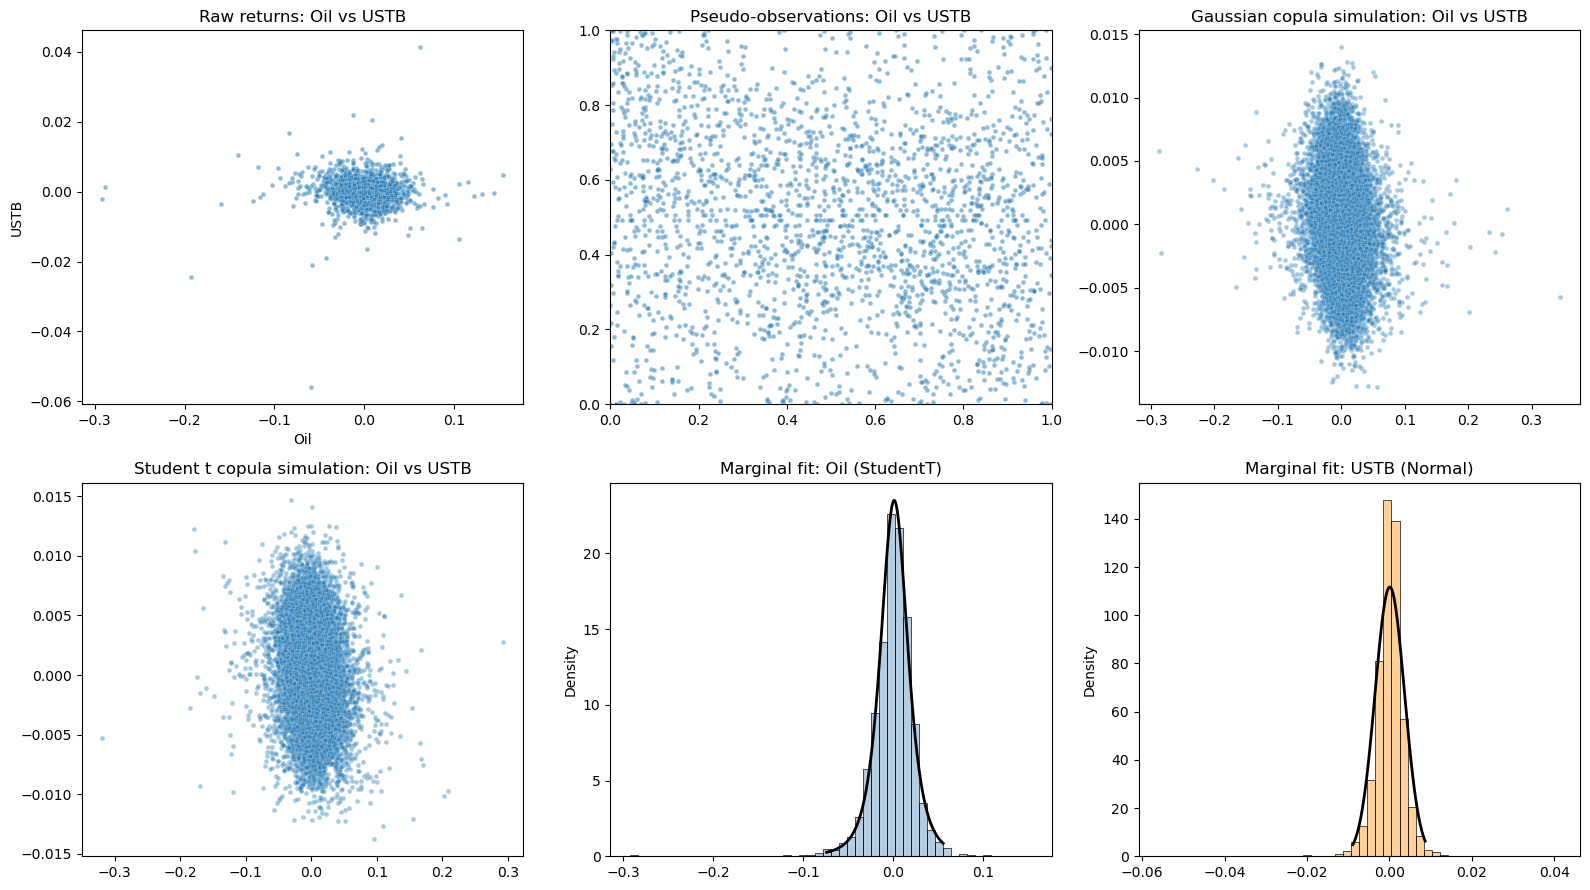


PARAMETER TABLE

          pair           model component  parameter   estimate
0   SP500-ASML        Marginal     SP500         df   2.609238
1   SP500-ASML        Marginal     SP500        loc   0.000991
2   SP500-ASML        Marginal     SP500      scale   0.006458
3   SP500-ASML        Marginal      ASML         df   3.740838
4   SP500-ASML        Marginal      ASML        loc   0.001432
5   SP500-ASML        Marginal      ASML      scale   0.015550
6   SP500-ASML  GaussianCopula    copula        rho   0.499493
7   SP500-ASML  StudentTCopula    copula        rho   0.499493
8   SP500-ASML  StudentTCopula    copula  df_copula   4.100000
9    Shell-EUB        Marginal     Shell         df   2.651728
10   Shell-EUB        Marginal     Shell        loc   0.000982
11   Shell-EUB        Marginal     Shell      scale   0.010101
12   Shell-EUB        Marginal       EUB        loc  -0.000014
13   Shell-EUB        Marginal       EUB      scale   0.003485
14   Shell-EUB  GaussianCopula    cop

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import kendalltau, spearmanr, pearsonr
from statsmodels.distributions.copula.api import (
    CopulaDistribution,
    GaussianCopula,
    StudentTCopula
)

# =========================
# USER INPUT
# =========================
pairs = [['SP500', 'ASML'], ['Shell', 'EUB'], ['Oil', 'USTB']]
bond_assets = {'EUB', 'USTB'}

# bootstrap size
B = 250

# simulated draws for model-implied dependence measures
N_SIM = 20000

# grid for Student t copula df estimation
T_DF_GRID = np.arange(2.1, 30.1, 0.5)

# empirical tail threshold
ALPHA = 0.05

# random seed
SEED = 42
rng = np.random.default_rng(SEED)

# =========================
# HELPERS
# =========================
def fit_marginal(x, asset_name):
    x = pd.Series(x).dropna().values

    if asset_name in bond_assets:
        params = stats.norm.fit(x)   # loc, scale
        dist = stats.norm(*params)
        family = 'Normal'
    else:
        params = stats.t.fit(x)      # df, loc, scale
        dist = stats.t(*params)
        family = 'StudentT'

    return {
        'family': family,
        'params': params,
        'dist': dist
    }

def make_uv(x, fit_x, y, fit_y, eps=1e-6):
    u = fit_x['dist'].cdf(np.asarray(x))
    v = fit_y['dist'].cdf(np.asarray(y))
    uv = np.column_stack([u, v])
    uv = np.clip(uv, eps, 1 - eps)
    return uv

def empirical_dependence(x, y, alpha=0.05):
    x = np.asarray(x)
    y = np.asarray(y)

    pear = pearsonr(x, y)[0]
    tau = kendalltau(x, y)[0]
    rho_s = spearmanr(x, y)[0]

    qx_l, qx_u = np.quantile(x, [alpha, 1 - alpha])
    qy_l, qy_u = np.quantile(y, [alpha, 1 - alpha])

    lower = np.mean((x <= qx_l) & (y <= qy_l)) / alpha
    upper = np.mean((x >= qx_u) & (y >= qy_u)) / alpha

    return {
        'pearson': pear,
        'kendall_tau': tau,
        'spearman_rho': rho_s,
        'lower_tail_emp': lower,
        'upper_tail_emp': upper
    }

def gaussian_tail_dependence():
    return 0.0, 0.0

def student_t_tail_dependence(rho, nu):
    # symmetric tail dependence for t copula
    # lambda_U = lambda_L = 2 * t_{nu+1}(-sqrt((nu+1)*(1-rho)/(1+rho)))
    val = 2 * stats.t.cdf(
        -np.sqrt((nu + 1) * (1 - rho) / (1 + rho)),
        df=nu + 1
    )
    return val, val

def fit_gaussian_copula(uv):
    cop = GaussianCopula()
    rho = float(cop.fit_corr_param(uv))
    cop = GaussianCopula(corr=rho)
    return {
        'family': 'Gaussian',
        'copula': cop,
        'rho': rho,
        'df_copula': np.nan,
        'loglik': np.sum(np.log(np.maximum(cop.pdf(uv), 1e-300)))
    }

def fit_student_t_copula(uv, df_grid=T_DF_GRID):
    # statsmodels fit_corr_param gives rho from Kendall tau;
    # we estimate df by grid search on pseudo-loglikelihood
    base = StudentTCopula(df=5)
    rho = float(base.fit_corr_param(uv))

    best = None
    best_ll = -np.inf

    for nu in df_grid:
        cop = StudentTCopula(corr=rho, df=nu)
        ll = np.sum(np.log(np.maximum(cop.pdf(uv), 1e-300)))
        if ll > best_ll:
            best_ll = ll
            best = (nu, cop)

    nu_hat, cop_hat = best
    return {
        'family': 'StudentT',
        'copula': cop_hat,
        'rho': rho,
        'df_copula': float(nu_hat),
        'loglik': float(best_ll)
    }

def fit_pair(df_pair, a, b):
    x = df_pair[a].values
    y = df_pair[b].values

    fit_a = fit_marginal(x, a)
    fit_b = fit_marginal(y, b)

    uv = make_uv(x, fit_a, y, fit_b)

    g_fit = fit_gaussian_copula(uv)
    t_fit = fit_student_t_copula(uv)

    g_joint = CopulaDistribution(
        copula=g_fit['copula'],
        marginals=[fit_a['dist'], fit_b['dist']]
    )

    t_joint = CopulaDistribution(
        copula=t_fit['copula'],
        marginals=[fit_a['dist'], fit_b['dist']]
    )

    empirical = empirical_dependence(x, y, alpha=ALPHA)

    g_tail_l, g_tail_u = gaussian_tail_dependence()
    t_tail_l, t_tail_u = student_t_tail_dependence(t_fit['rho'], t_fit['df_copula'])

    # simulate model-implied dependence measures on raw-return scale
    sim_g = g_joint.rvs(N_SIM, random_state=123)
    sim_t = t_joint.rvs(N_SIM, random_state=456)

    model_g = empirical_dependence(sim_g[:, 0], sim_g[:, 1], alpha=ALPHA)
    model_t = empirical_dependence(sim_t[:, 0], sim_t[:, 1], alpha=ALPHA)

    model_g['lower_tail_model'] = g_tail_l
    model_g['upper_tail_model'] = g_tail_u

    model_t['lower_tail_model'] = t_tail_l
    model_t['upper_tail_model'] = t_tail_u

    return {
        'pair': f'{a}-{b}',
        'assets': (a, b),
        'data': df_pair.copy(),
        'fit_a': fit_a,
        'fit_b': fit_b,
        'uv': uv,
        'gaussian': {**g_fit, 'joint': g_joint, 'sim': sim_g, 'measures': model_g},
        'student_t': {**t_fit, 'joint': t_joint, 'sim': sim_t, 'measures': model_t},
        'empirical': empirical
    }

def summarize_parameters(result):
    a, b = result['assets']
    rows = []

    # marginal A
    fa = result['fit_a']
    if fa['family'] == 'Normal':
        rows += [
            {'pair': result['pair'], 'model': 'Marginal', 'component': a, 'parameter': 'loc', 'estimate': fa['params'][0]},
            {'pair': result['pair'], 'model': 'Marginal', 'component': a, 'parameter': 'scale', 'estimate': fa['params'][1]},
        ]
    else:
        rows += [
            {'pair': result['pair'], 'model': 'Marginal', 'component': a, 'parameter': 'df', 'estimate': fa['params'][0]},
            {'pair': result['pair'], 'model': 'Marginal', 'component': a, 'parameter': 'loc', 'estimate': fa['params'][1]},
            {'pair': result['pair'], 'model': 'Marginal', 'component': a, 'parameter': 'scale', 'estimate': fa['params'][2]},
        ]

    # marginal B
    fb = result['fit_b']
    if fb['family'] == 'Normal':
        rows += [
            {'pair': result['pair'], 'model': 'Marginal', 'component': b, 'parameter': 'loc', 'estimate': fb['params'][0]},
            {'pair': result['pair'], 'model': 'Marginal', 'component': b, 'parameter': 'scale', 'estimate': fb['params'][1]},
        ]
    else:
        rows += [
            {'pair': result['pair'], 'model': 'Marginal', 'component': b, 'parameter': 'df', 'estimate': fb['params'][0]},
            {'pair': result['pair'], 'model': 'Marginal', 'component': b, 'parameter': 'loc', 'estimate': fb['params'][1]},
            {'pair': result['pair'], 'model': 'Marginal', 'component': b, 'parameter': 'scale', 'estimate': fb['params'][2]},
        ]

    # copulas
    rows += [
        {'pair': result['pair'], 'model': 'GaussianCopula', 'component': 'copula', 'parameter': 'rho', 'estimate': result['gaussian']['rho']},
        {'pair': result['pair'], 'model': 'StudentTCopula', 'component': 'copula', 'parameter': 'rho', 'estimate': result['student_t']['rho']},
        {'pair': result['pair'], 'model': 'StudentTCopula', 'component': 'copula', 'parameter': 'df_copula', 'estimate': result['student_t']['df_copula']},
    ]

    return pd.DataFrame(rows)

def summarize_dependence(result):
    rows = []
    pair = result['pair']

    emp = result['empirical']
    rows.append({
        'pair': pair,
        'source': 'Empirical',
        'pearson': emp['pearson'],
        'kendall_tau': emp['kendall_tau'],
        'spearman_rho': emp['spearman_rho'],
        'lower_tail': emp['lower_tail_emp'],
        'upper_tail': emp['upper_tail_emp']
    })

    for label, key in [('Gaussian', 'gaussian'), ('StudentT', 'student_t')]:
        m = result[key]['measures']
        rows.append({
            'pair': pair,
            'source': label,
            'pearson': m['pearson'],
            'kendall_tau': m['kendall_tau'],
            'spearman_rho': m['spearman_rho'],
            'lower_tail': m['lower_tail_model'],
            'upper_tail': m['upper_tail_model']
        })

    return pd.DataFrame(rows)

def bootstrap_pair(df_pair, a, b, B=250, seed=42):
    rng = np.random.default_rng(seed)
    n = len(df_pair)
    boot_rows = []

    for _ in range(B):
        idx = rng.integers(0, n, n)
        sample = df_pair.iloc[idx].reset_index(drop=True)

        x = sample[a].values
        y = sample[b].values

        fit_a = fit_marginal(x, a)
        fit_b = fit_marginal(y, b)
        uv = make_uv(x, fit_a, y, fit_b)

        g = fit_gaussian_copula(uv)
        t = fit_student_t_copula(uv)

        # Gaussian row
        row_g = {
            'pair': f'{a}-{b}',
            'copula': 'Gaussian',
            'rho': g['rho']
        }
        if fit_a['family'] == 'Normal':
            row_g['p1_loc'] = fit_a['params'][0]
            row_g['p1_scale'] = fit_a['params'][1]
        else:
            row_g['p1_df'] = fit_a['params'][0]
            row_g['p1_loc'] = fit_a['params'][1]
            row_g['p1_scale'] = fit_a['params'][2]

        if fit_b['family'] == 'Normal':
            row_g['p2_loc'] = fit_b['params'][0]
            row_g['p2_scale'] = fit_b['params'][1]
        else:
            row_g['p2_df'] = fit_b['params'][0]
            row_g['p2_loc'] = fit_b['params'][1]
            row_g['p2_scale'] = fit_b['params'][2]

        # Student t copula row
        row_t = row_g.copy()
        row_t['copula'] = 'StudentT'
        row_t['rho'] = t['rho']
        row_t['df_copula'] = t['df_copula']

        boot_rows.append(row_g)
        boot_rows.append(row_t)

    boot = pd.DataFrame(boot_rows)

    out = []
    id_cols = ['pair', 'copula']
    param_cols = [c for c in boot.columns if c not in id_cols]

    for (pair_name, cop_name), gdf in boot.groupby(id_cols):
        for col in param_cols:
            vals = gdf[col].dropna().values
            if len(vals) == 0:
                continue
            out.append({
                'parameter': col,
                'estimate': np.mean(vals),
                'std_error': np.std(vals, ddof=1),
                'ci_low_95': np.quantile(vals, 0.025),
                'ci_high_95': np.quantile(vals, 0.975),
                'pair': pair_name,
                'copula': cop_name
            })

    return pd.DataFrame(out), boot

def plot_pair_results(result):
    a, b = result['assets']
    df_pair = result['data']
    uv = result['uv']
    sim_g = result['gaussian']['sim']
    sim_t = result['student_t']['sim']

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))

    # raw returns
    sns.scatterplot(x=df_pair[a], y=df_pair[b], s=12, alpha=0.5, ax=axes[0, 0])
    axes[0, 0].set_title(f'Raw returns: {a} vs {b}')

    # pseudo-observations
    sns.scatterplot(x=uv[:, 0], y=uv[:, 1], s=12, alpha=0.5, ax=axes[0, 1])
    axes[0, 1].set_title(f'Pseudo-observations: {a} vs {b}')
    axes[0, 1].set_xlim(0, 1)
    axes[0, 1].set_ylim(0, 1)

    # gaussian simulated
    sns.scatterplot(x=sim_g[:, 0], y=sim_g[:, 1], s=12, alpha=0.4, ax=axes[0, 2])
    axes[0, 2].set_title(f'Gaussian copula simulation: {a} vs {b}')

    # student t simulated
    sns.scatterplot(x=sim_t[:, 0], y=sim_t[:, 1], s=12, alpha=0.4, ax=axes[1, 0])
    axes[1, 0].set_title(f'Student t copula simulation: {a} vs {b}')

    # histogram + fitted density asset 1
    x = df_pair[a].values
    xs = np.linspace(np.quantile(x, 0.01), np.quantile(x, 0.99), 500)
    sns.histplot(x, stat='density', bins=50, color='steelblue', alpha=0.4, ax=axes[1, 1])
    axes[1, 1].plot(xs, result['fit_a']['dist'].pdf(xs), color='black', lw=2)
    axes[1, 1].set_title(f'Marginal fit: {a} ({result["fit_a"]["family"]})')

    # histogram + fitted density asset 2
    y = df_pair[b].values
    ys = np.linspace(np.quantile(y, 0.01), np.quantile(y, 0.99), 500)
    sns.histplot(y, stat='density', bins=50, color='darkorange', alpha=0.4, ax=axes[1, 2])
    axes[1, 2].plot(ys, result['fit_b']['dist'].pdf(ys), color='black', lw=2)
    axes[1, 2].set_title(f'Marginal fit: {b} ({result["fit_b"]["family"]})')

    plt.tight_layout()
    plt.show()

# RUN EVERYTHING
all_results = {}
param_tables = []
dep_tables = []
boot_summaries = []

for a, b in pairs:
    df_pair = returns[[a, b]].dropna().copy()

    res = fit_pair(df_pair, a, b)
    all_results[f'{a}-{b}'] = res

    plot_pair_results(res)

    param_tables.append(summarize_parameters(res))
    dep_tables.append(summarize_dependence(res))

    boot_summary, boot_raw = bootstrap_pair(df_pair, a, b, B=B, seed=SEED)
    boot_summaries.append(boot_summary)

param_table = pd.concat(param_tables, ignore_index=True)
dependence_table = pd.concat(dep_tables, ignore_index=True)
bootstrap_table = pd.concat(boot_summaries, ignore_index=True)

# nicer display
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 180)

print("\nPARAMETER TABLE\n")
print(param_table.round(6))

print("\nDEPENDENCE COMPARISON TABLE\n")
print(dependence_table.round(6))

print("\nBOOTSTRAP PRECISION TABLE\n")
print(bootstrap_table.round(6))

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

os.makedirs("copula_surfaces", exist_ok=True)

def copula_surface_data(copula, n_grid=80, eps=1e-4):
    u = np.linspace(eps, 1 - eps, n_grid)
    v = np.linspace(eps, 1 - eps, n_grid)
    U, V = np.meshgrid(u, v)
    UV = np.column_stack([U.ravel(), V.ravel()])
    Z = copula.pdf(UV).reshape(n_grid, n_grid)
    return u, v, U, V, Z

def save_plotly_surface(copula, pair_name, copula_name, out_dir="copula_surfaces", n_grid=80):
    u, v, U, V, Z = copula_surface_data(copula, n_grid=n_grid)

    fig = go.Figure(
        data=[
            go.Surface(
                x=u,
                y=v,
                z=Z,
                colorscale="Viridis",
                showscale=True,
                contours={
                    "z": {
                        "show": True,
                        "usecolormap": True,
                        "highlightcolor": "#444",
                        "project_z": True
                    }
                }
            )
        ]
    )

    fig.update_layout(
        title=f"{copula_name} copula density surface: {pair_name}",
        width=950,
        height=750,
        scene=dict(
            xaxis_title="u",
            yaxis_title="v",
            zaxis_title="c(u,v)",
            camera=dict(eye=dict(x=1.6, y=1.4, z=1.15))
        ),
        margin=dict(l=10, r=10, t=50, b=10)
    )

    file_html = os.path.join(out_dir, f"{pair_name}_{copula_name}_surface.html".replace(" ", "_"))
    fig.write_html(file_html)
    return fig, file_html

def save_contour_plot(copula, pair_name, copula_name, out_dir="copula_surfaces", n_grid=150):
    u, v, U, V, Z = copula_surface_data(copula, n_grid=n_grid)

    fig, ax = plt.subplots(figsize=(7, 6))
    cs = ax.contourf(U, V, Z, levels=20, cmap="viridis")
    cbar = fig.colorbar(cs, ax=ax)
    cbar.set_label("c(u,v)")
    ax.set_xlabel("u")
    ax.set_ylabel("v")
    ax.set_title(f"{copula_name} copula contour: {pair_name}")
    plt.tight_layout()

    file_png = os.path.join(out_dir, f"{pair_name}_{copula_name}_contour.png".replace(" ", "_"))
    plt.savefig(file_png, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return file_png

generated_files = []

for pair_name, res in all_results.items():
    copula_specs = [
        ("Gaussian", res["gaussian"]["copula"]),
        ("StudentT", res["student_t"]["copula"]),
    ]

    for copula_name, copula_obj in copula_specs:
        _, html_file = save_plotly_surface(
            copula=copula_obj,
            pair_name=pair_name,
            copula_name=copula_name,
            out_dir="copula_surfaces",
            n_grid=80
        )
        contour_file = save_contour_plot(
            copula=copula_obj,
            pair_name=pair_name,
            copula_name=copula_name,
            out_dir="copula_surfaces",
            n_grid=150
        )

        generated_files.append({
            "pair": pair_name,
            "copula": copula_name,
            "surface_html": html_file,
            "contour_png": contour_file
        })

generated_files_df = pd.DataFrame(generated_files)
print(generated_files_df)

         pair    copula                                      surface_html                                      contour_png
0  SP500-ASML  Gaussian  copula_surfaces/SP500-ASML_Gaussian_surface.html  copula_surfaces/SP500-ASML_Gaussian_contour.png
1  SP500-ASML  StudentT  copula_surfaces/SP500-ASML_StudentT_surface.html  copula_surfaces/SP500-ASML_StudentT_contour.png
2   Shell-EUB  Gaussian   copula_surfaces/Shell-EUB_Gaussian_surface.html   copula_surfaces/Shell-EUB_Gaussian_contour.png
3   Shell-EUB  StudentT   copula_surfaces/Shell-EUB_StudentT_surface.html   copula_surfaces/Shell-EUB_StudentT_contour.png
4    Oil-USTB  Gaussian    copula_surfaces/Oil-USTB_Gaussian_surface.html    copula_surfaces/Oil-USTB_Gaussian_contour.png
5    Oil-USTB  StudentT    copula_surfaces/Oil-USTB_StudentT_surface.html    copula_surfaces/Oil-USTB_StudentT_contour.png


In [14]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import pearsonr, kendalltau, spearmanr

pairs = [['SP500', 'ASML'], ['Shell', 'EUB'], ['Oil', 'USTB']]
bond_assets = {'EUB', 'USTB'}

def fit_marginal(x, name):
    x = pd.Series(x).dropna().values
    if name in bond_assets:
        params = stats.norm.fit(x)
        dist = stats.norm(*params)
        family = 'Normal'
    else:
        params = stats.t.fit(x)
        dist = stats.t(*params)
        family = 'StudentT'
    return family, params, dist

def empirical_measures(x, y, alpha=0.05):
    qx_l, qx_u = np.quantile(x, [alpha, 1-alpha])
    qy_l, qy_u = np.quantile(y, [alpha, 1-alpha])

    return {
        'pearson': pearsonr(x, y)[0],
        'kendall_tau': kendalltau(x, y)[0],
        'spearman_rho': spearmanr(x, y)[0],
        'lower_tail_emp': np.mean((x <= qx_l) & (y <= qy_l)) / alpha,
        'upper_tail_emp': np.mean((x >= qx_u) & (y >= qy_u)) / alpha,
    }

def student_t_tail_dependence(rho, nu):
    lam = 2 * stats.t.cdf(
        -np.sqrt((nu + 1) * (1 - rho) / (1 + rho)),
        df=nu + 1
    )
    return lam, lam

rows = []

for pair_name, res in all_results.items():
    a, b = res['assets']
    df_pair = returns[[a, b]].dropna()
    x, y = df_pair[a].values, df_pair[b].values

    emp = empirical_measures(x, y)

    sim_g = res['gaussian']['joint'].rvs(20000, random_state=1)
    sim_t = res['student_t']['joint'].rvs(20000, random_state=2)

    mod_g = empirical_measures(sim_g[:, 0], sim_g[:, 1])
    mod_t = empirical_measures(sim_t[:, 0], sim_t[:, 1])

    lt_g, ut_g = 0.0, 0.0
    lt_t, ut_t = student_t_tail_dependence(
        res['student_t']['rho'],
        res['student_t']['df_copula']
    )

    rows += [
        {
            'pair': pair_name, 'source': 'Empirical',
            'pearson': emp['pearson'],
            'kendall_tau': emp['kendall_tau'],
            'spearman_rho': emp['spearman_rho'],
            'lower_tail': emp['lower_tail_emp'],
            'upper_tail': emp['upper_tail_emp']
        },
        {
            'pair': pair_name, 'source': 'Gaussian',
            'pearson': mod_g['pearson'],
            'kendall_tau': mod_g['kendall_tau'],
            'spearman_rho': mod_g['spearman_rho'],
            'lower_tail': lt_g,
            'upper_tail': ut_g
        },
        {
            'pair': pair_name, 'source': 'StudentT',
            'pearson': mod_t['pearson'],
            'kendall_tau': mod_t['kendall_tau'],
            'spearman_rho': mod_t['spearman_rho'],
            'lower_tail': lt_t,
            'upper_tail': ut_t
        }
    ]

dependence_table = pd.DataFrame(rows)

In [15]:
for pair in dependence_table['pair'].unique():
    print('\n', pair)
    print(dependence_table[dependence_table['pair'] == pair].round(4))


 SP500-ASML
         pair     source  pearson  kendall_tau  spearman_rho  lower_tail  upper_tail
0  SP500-ASML  Empirical   0.4359       0.3330        0.4686      0.3105      0.2846
1  SP500-ASML   Gaussian   0.4480       0.3396        0.4912      0.0000      0.0000
2  SP500-ASML   StudentT   0.4830       0.3215        0.4518      0.2478      0.2478

 Shell-EUB
        pair     source  pearson  kendall_tau  spearman_rho  lower_tail  upper_tail
3  Shell-EUB  Empirical  -0.1034      -0.0887       -0.1301      0.0604      0.0517
4  Shell-EUB   Gaussian  -0.1354      -0.0958       -0.1434      0.0000      0.0000
5  Shell-EUB   StudentT  -0.1173      -0.0870       -0.1286      0.0022      0.0022

 Oil-USTB
       pair     source  pearson  kendall_tau  spearman_rho  lower_tail  upper_tail
6  Oil-USTB  Empirical  -0.0492      -0.0909       -0.1322      0.0690      0.0862
7  Oil-USTB   Gaussian  -0.1463      -0.0980       -0.1467      0.0000      0.0000
8  Oil-USTB   StudentT  -0.1308      -0

In [ ]:
from scipy.stats import gaussian_kde

def aic_bic(loglik, k, n):
    return -2 * loglik + 2 * k, -2 * loglik + k * np.log(n)

aic_bic_rows = []

for pair_name, res in all_results.items():
    uv = res['uv']
    n  = len(uv)

    # --- Gaussian copula: k=1 (rho only) ---
    ll_g = res['gaussian']['loglik']
    aic_g, bic_g = aic_bic(ll_g, k=1, n=n)

    # --- Student t copula: k=2 (rho + df) ---
    ll_t = res['student_t']['loglik']
    aic_t, bic_t = aic_bic(ll_t, k=2, n=n)

    # --- Empirical copula: kernel density on pseudo-obs ---
    kde = gaussian_kde(uv.T)
    ll_emp = np.sum(np.log(np.maximum(kde(uv.T), 1e-300)))
    # empirical: no free parameters, use k=0 for reference
    aic_emp, bic_emp = aic_bic(ll_emp, k=0, n=n)

    aic_bic_rows += [
        {'pair': pair_name, 'model': 'Empirical (KDE)', 'loglik': ll_emp, 'k': 0, 'AIC': aic_emp, 'BIC': bic_emp},
        {'pair': pair_name, 'model': 'Gaussian',        'loglik': ll_g,   'k': 1, 'AIC': aic_g,   'BIC': bic_g},
        {'pair': pair_name, 'model': 'StudentT',        'loglik': ll_t,   'k': 2, 'AIC': aic_t,   'BIC': bic_t},
    ]

aic_bic_table = pd.DataFrame(aic_bic_rows)
print(aic_bic_table.round(2))

         pair            model  loglik  k     AIC     BIC
0  SP500-ASML  Empirical (KDE)   18.44  0  -36.89  -36.89
1  SP500-ASML         Gaussian  296.22  1 -590.44 -584.69
2  SP500-ASML         StudentT  363.35  2 -722.70 -711.20
3   Shell-EUB  Empirical (KDE) -208.46  0  416.92  416.92
4   Shell-EUB         Gaussian   18.44  1  -34.88  -29.13
5   Shell-EUB         StudentT   43.85  2  -83.71  -72.21
6    Oil-USTB  Empirical (KDE)  -69.19  0  138.39  138.39
7    Oil-USTB         Gaussian   10.96  1  -19.91  -14.17
8    Oil-USTB         StudentT   43.97  2  -83.94  -72.44


## EVT

EVT input data
------------------------------------------------------------
Number of observations: 2319
Assets: ['ASML', 'Shell', 'Walmart', 'USTB', 'EUB', 'AEX', 'SP500', 'Gold', 'Oil', 'Iron']

Tail diagnostic summary
------------------------------------------------------------
         mean_return  std_return  skew_return  excess_kurtosis_return  loss_95pct  loss_99pct
Ticker                                                                                       
USTB        0.000077    0.003572    -1.131628               36.883156    0.005129    0.008884
Oil         0.000215    0.025094    -1.733974               20.678446    0.035880    0.073721
Shell       0.000362    0.018181    -0.567059               19.448471    0.027199    0.052325
SP500       0.000496    0.011698    -0.659160               16.463213    0.017217    0.034235
Walmart     0.000809    0.013897     0.041392               13.576703    0.018997    0.032835
AEX         0.000308    0.010383    -0.872542               

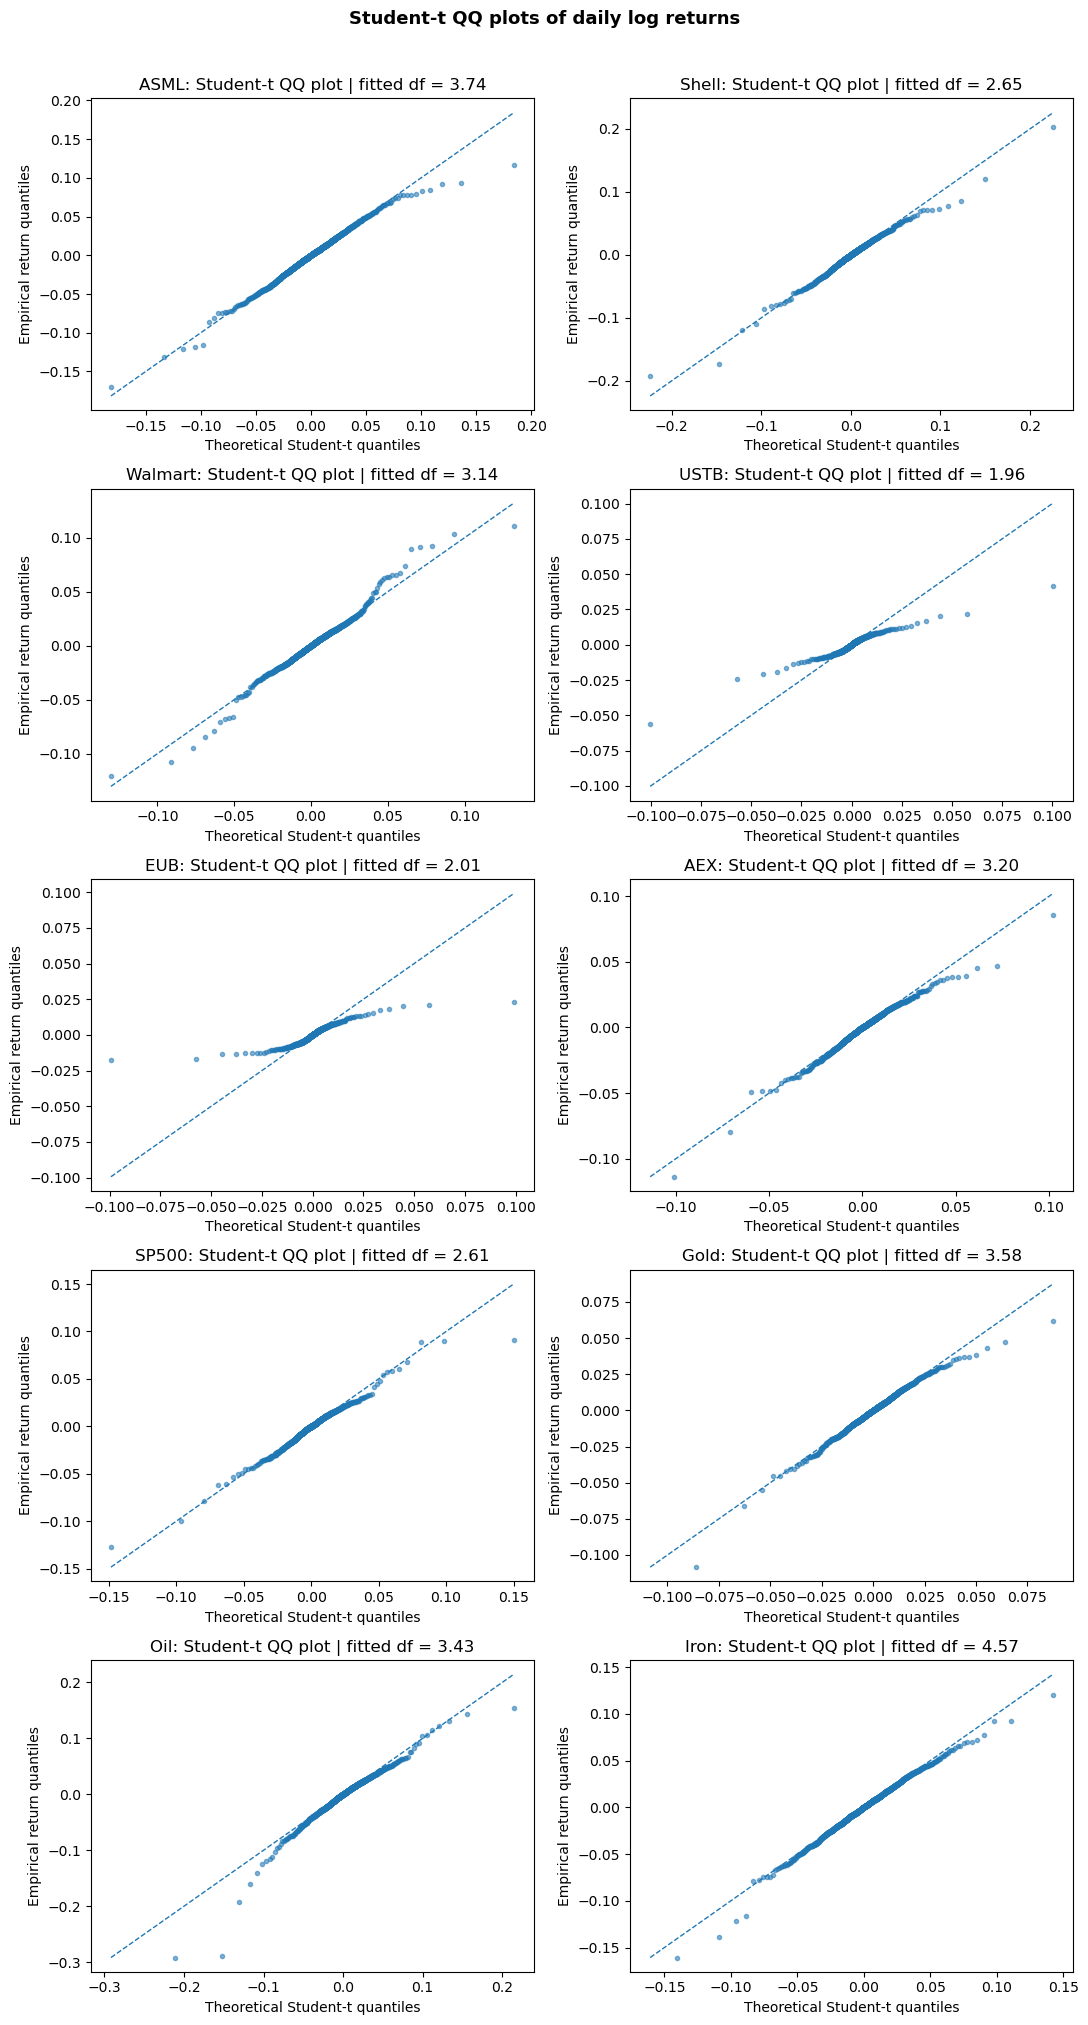


Selected EVT asset
------------------------------------------------------------
Asset with highest excess kurtosis: USTB
Excess kurtosis: 36.8832
Loss 95% quantile: 0.5129%
Loss 99% quantile: 0.8884%

Threshold diagnostics
------------------------------------------------------------
 threshold_prob  threshold_u  n_exceedances  exceedance_share  xi_shape  beta_scale  mean_excess
           0.90     0.003544            232          0.100043  0.205856    0.002021     0.002605
           0.91     0.003796            209          0.090125  0.224058    0.001985     0.002625
           0.92     0.004110            186          0.080207  0.267444    0.001863     0.002613
           0.93     0.004446            163          0.070289  0.322248    0.001738     0.002623
           0.94     0.004742            140          0.060371  0.342072    0.001761     0.002734
           0.95     0.005129            116          0.050022  0.362374    0.001802     0.002884
           0.96     0.005546        

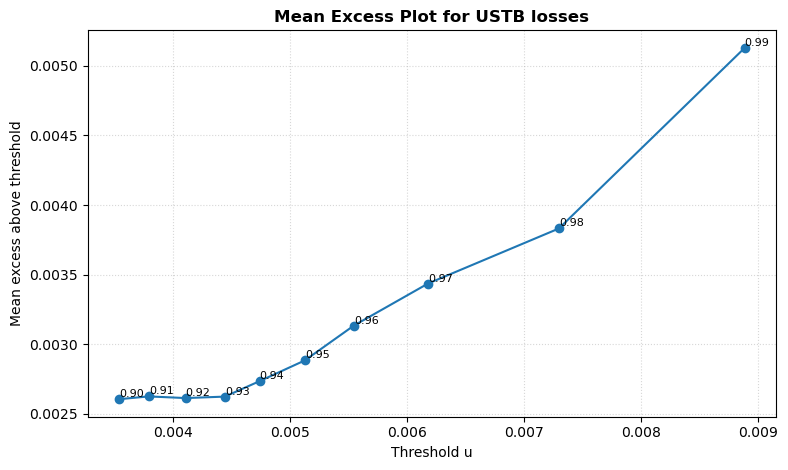

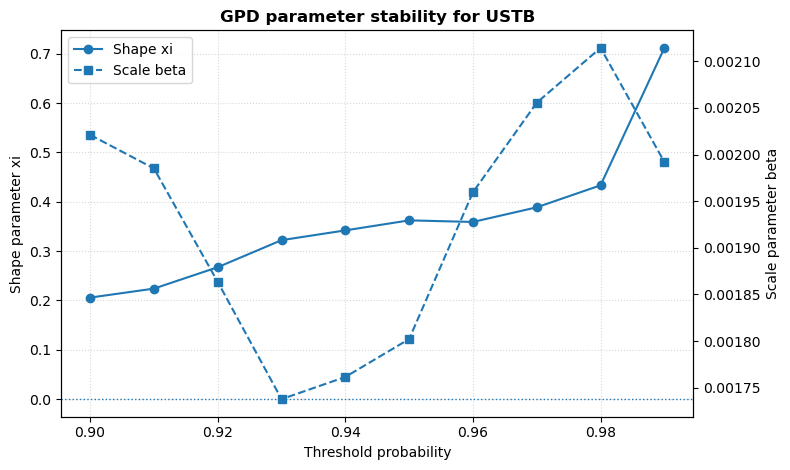


Final POT-GPD fit
------------------------------------------------------------
Asset: USTB
Threshold probability: 95.00%
Threshold u: 0.005129
Number of observations: 2319
Number of exceedances: 116
Exceedance share: 5.0022%
Shape xi: 0.362374
Scale beta: 0.001802


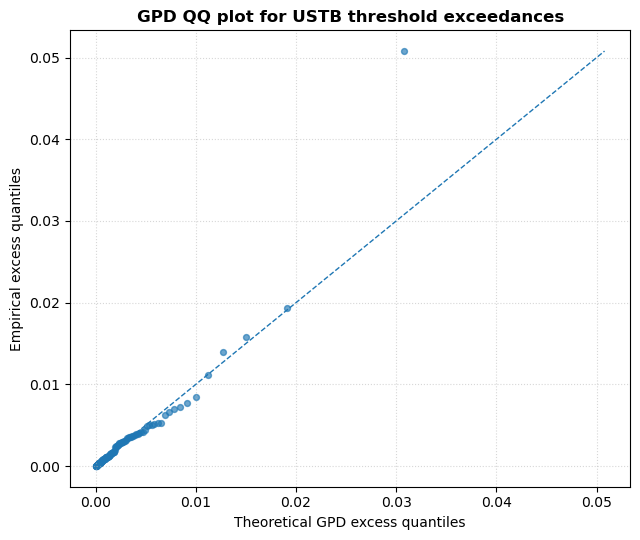

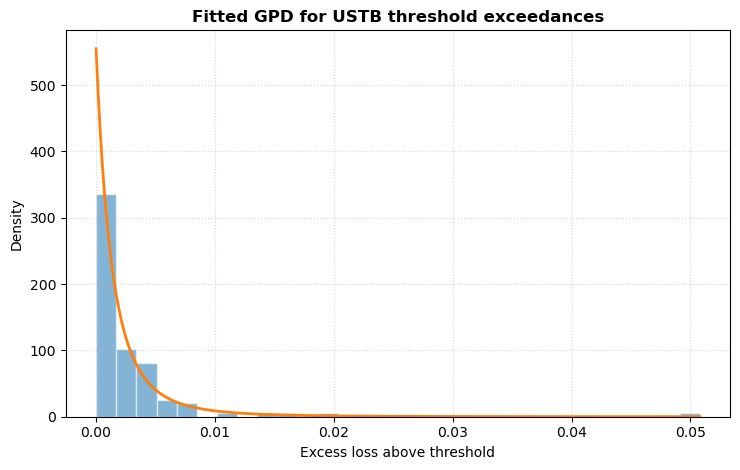


VaR and ES comparison
------------------------------------------------------------
asset  alpha                method  VaR_loss  ES_loss
 USTB  0.950 Historical simulation  0.005129 0.008012
 USTB  0.950           EVT POT-GPD  0.005130 0.007956
 USTB  0.950     GARCH + Student-t  0.004157 0.005631
 USTB  0.975 Historical simulation  0.006537 0.010303
 USTB  0.975           EVT POT-GPD  0.006550 0.010184
 USTB  0.975     GARCH + Student-t  0.005172 0.006654
 USTB  0.990 Historical simulation  0.008884 0.014013
 USTB  0.990           EVT POT-GPD  0.009068 0.014133
 USTB  0.990     GARCH + Student-t  0.006500 0.008031

LaTeX table: VaR and ES comparison
\begin{tabular}{lrlrr}
\toprule
asset & alpha & method & VaR_loss & ES_loss \\
\midrule
USTB & 0.950000 & Historical simulation & 0.005129 & 0.008012 \\
USTB & 0.950000 & EVT POT-GPD & 0.005130 & 0.007956 \\
USTB & 0.950000 & GARCH + Student-t & 0.004157 & 0.005631 \\
USTB & 0.975000 & Historical simulation & 0.006537 & 0.010303 \\
USTB &

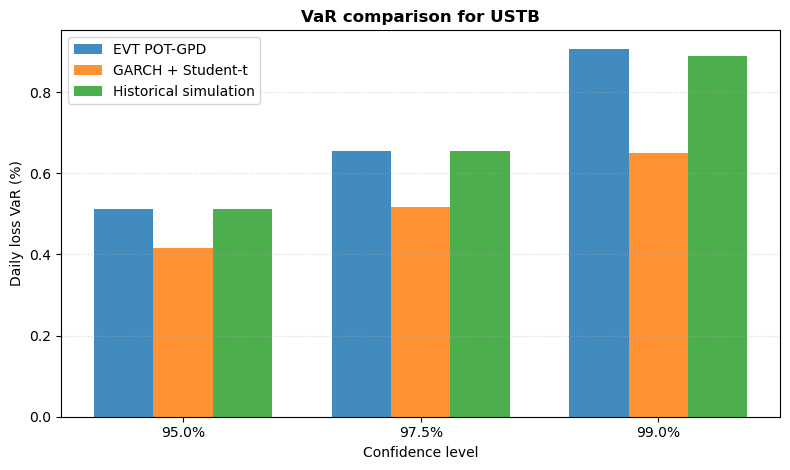

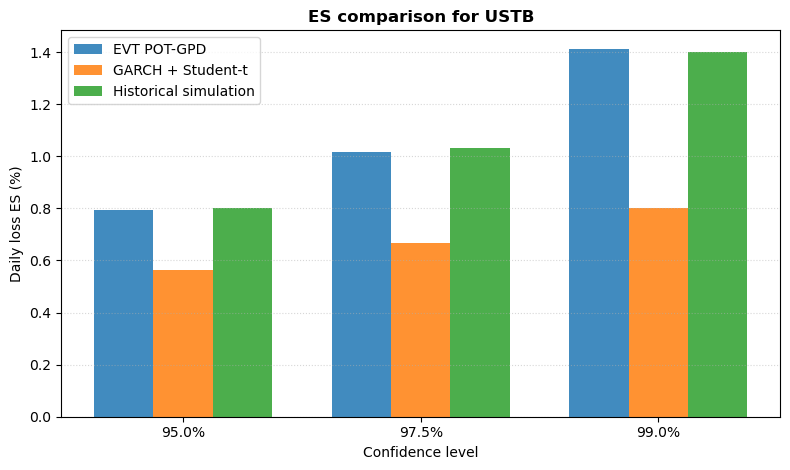


GARCH + Student-t details
------------------------------------------------------------
Asset: USTB
Estimated Student-t degrees of freedom: 8.6993
One-step-ahead conditional volatility: 0.2666%
One-step-ahead 99% VaR loss: 0.6500%
One-step-ahead 99% ES loss: 0.8031%

GARCH parameter estimates
mu          0.014886
omega       0.001366
alpha[1]    0.115067
beta[1]     0.875269
nu          8.699334

Final EVT summary
------------------------------------------------------------
                  Item                   Value
        Selected asset                    USTB
   Selection criterion Highest excess kurtosis
 Threshold probability                  95.00%
           Threshold u                0.005129
Number of observations                    2319
 Number of exceedances                     116
      Exceedance share                 5.0022%
          GPD shape xi                0.362374
        GPD scale beta                0.001802

LaTeX table: Final EVT summary
\begin{tabular}{ll}

In [10]:
# This section studies the most extreme negative returns. We work with losses:
#
#     loss_t = - return_t
#
# A large loss therefore means a large negative asset return.


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from arch import arch_model

# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------
# The code assumes that the previous setup already created a DataFrame called returns,
# with daily log returns and asset names as columns.

asset_order = ["ASML", "Shell", "Walmart", "USTB", "EUB", "AEX", "SP500", "Gold", "Oil", "Iron"]
asset_order = [a for a in asset_order if a in returns.columns]

R = returns[asset_order].dropna().copy()
losses = -R

print("EVT input data")
print("-" * 60)
print(f"Number of observations: {len(R)}")
print(f"Assets: {asset_order}")



# ------------------------------------------------------------
# 1. Tail diagnostics: kurtosis and Student-t QQ plots
# ------------------------------------------------------------

tail_summary = pd.DataFrame({
    "mean_return": R.mean(),
    "std_return": R.std(),
    "skew_return": R.skew(),
    "excess_kurtosis_return": R.kurtosis(),
    "loss_95pct": losses.quantile(0.95),
    "loss_99pct": losses.quantile(0.99),
}).sort_values("excess_kurtosis_return", ascending=False)

print("\nTail diagnostic summary")
print("-" * 60)
print(tail_summary.round(6).to_string())

print("\nLaTeX table: Tail diagnostic summary")
print(tail_summary.round(6).to_latex(float_format="%.6f"))



# Student-t QQ plots for all assets.
# For each asset, we fit a Student-t distribution and compare theoretical vs empirical quantiles.

n_assets = len(asset_order)
ncols = 2
nrows = int(np.ceil(n_assets / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(11, 4 * nrows))
axes = axes.flatten()

for i, asset in enumerate(asset_order):
    x = R[asset].dropna().values

    # Fit Student-t distribution: df, loc, scale
    df_t, loc_t, scale_t = stats.t.fit(x)

    p = (np.arange(1, len(x) + 1) - 0.5) / len(x)
    theoretical_q = stats.t.ppf(p, df=df_t, loc=loc_t, scale=scale_t)
    empirical_q = np.sort(x)

    axes[i].scatter(theoretical_q, empirical_q, s=9, alpha=0.55)

    mn = min(theoretical_q.min(), empirical_q.min())
    mx = max(theoretical_q.max(), empirical_q.max())
    axes[i].plot([mn, mx], [mn, mx], linestyle="--", linewidth=1)

    axes[i].set_title(f"{asset}: Student-t QQ plot | fitted df = {df_t:.2f}")
    axes[i].set_xlabel("Theoretical Student-t quantiles")
    axes[i].set_ylabel("Empirical return quantiles")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Student-t QQ plots of daily log returns", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()



# ------------------------------------------------------------
# 2. Select asset with the heaviest tails
# ------------------------------------------------------------
# We select the asset with the largest excess kurtosis.
# This is simple, transparent, and directly linked to the assignment question.

evt_asset = tail_summary.index[0]
x_ret = R[evt_asset].dropna()
x_loss = -x_ret

print("\nSelected EVT asset")
print("-" * 60)
print(f"Asset with highest excess kurtosis: {evt_asset}")
print(f"Excess kurtosis: {tail_summary.loc[evt_asset, 'excess_kurtosis_return']:.4f}")
print(f"Loss 95% quantile: {tail_summary.loc[evt_asset, 'loss_95pct']:.4%}")
print(f"Loss 99% quantile: {tail_summary.loc[evt_asset, 'loss_99pct']:.4%}")



# ------------------------------------------------------------
# 3. Threshold diagnostics for Peak-over-Threshold
# ------------------------------------------------------------
# We fit EVT to losses above a high threshold u.
# Threshold choice is a trade-off:
# - too low: observations are not truly extreme
# - too high: too few observations remain
#
# We inspect several thresholds before choosing one.

threshold_probs = np.arange(0.90, 0.991, 0.01)

threshold_rows = []

for q in threshold_probs:
    u = x_loss.quantile(q)
    exceedances = x_loss[x_loss > u] - u
    n_exc = len(exceedances)

    if n_exc < 20:
        continue

    # Fit GPD to exceedances over threshold, fixing location at 0.
    xi, loc, beta = stats.genpareto.fit(exceedances, floc=0)

    threshold_rows.append({
        "threshold_prob": q,
        "threshold_u": u,
        "n_exceedances": n_exc,
        "exceedance_share": n_exc / len(x_loss),
        "xi_shape": xi,
        "beta_scale": beta,
        "mean_excess": exceedances.mean(),
    })

threshold_diagnostics = pd.DataFrame(threshold_rows)

print("\nThreshold diagnostics")
print("-" * 60)
print(threshold_diagnostics.round(6).to_string(index=False))

print("\nLaTeX table: Threshold diagnostics")
print(threshold_diagnostics.round(6).to_latex(index=False, float_format="%.6f"))



# Plot 1: Mean excess plot
# If the GPD approximation is reasonable, the mean excess function should be roughly linear
# over a high-threshold region.

fig, ax = plt.subplots(figsize=(8, 4.8))

ax.plot(
    threshold_diagnostics["threshold_u"],
    threshold_diagnostics["mean_excess"],
    marker="o",
    linewidth=1.5,
)

for _, row in threshold_diagnostics.iterrows():
    ax.text(
        row["threshold_u"],
        row["mean_excess"],
        f"{row['threshold_prob']:.2f}",
        fontsize=8,
        ha="left",
        va="bottom",
    )

ax.set_title(f"Mean Excess Plot for {evt_asset} losses", fontweight="bold")
ax.set_xlabel("Threshold u")
ax.set_ylabel("Mean excess above threshold")
ax.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()



# Plot 2: Stability of GPD parameters across thresholds
# We want xi and beta to be reasonably stable around the chosen threshold.

fig, ax1 = plt.subplots(figsize=(8, 4.8))
ax2 = ax1.twinx()

ax1.plot(
    threshold_diagnostics["threshold_prob"],
    threshold_diagnostics["xi_shape"],
    marker="o",
    linewidth=1.5,
    label="Shape xi",
)

ax2.plot(
    threshold_diagnostics["threshold_prob"],
    threshold_diagnostics["beta_scale"],
    marker="s",
    linestyle="--",
    linewidth=1.5,
    label="Scale beta",
)

ax1.axhline(0, linestyle=":", linewidth=1)
ax1.set_title(f"GPD parameter stability for {evt_asset}", fontweight="bold")
ax1.set_xlabel("Threshold probability")
ax1.set_ylabel("Shape parameter xi")
ax2.set_ylabel("Scale parameter beta")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

ax1.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()



# ------------------------------------------------------------
# 4. Choose threshold and fit final GPD
# ------------------------------------------------------------

THRESHOLD_PROB = 0.95

u = x_loss.quantile(THRESHOLD_PROB)
exceedances = x_loss[x_loss > u] - u
n = len(x_loss)
n_u = len(exceedances)
p_u = n_u / n

xi_hat, loc_hat, beta_hat = stats.genpareto.fit(exceedances, floc=0)

print("\nFinal POT-GPD fit")
print("-" * 60)
print(f"Asset: {evt_asset}")
print(f"Threshold probability: {THRESHOLD_PROB:.2%}")
print(f"Threshold u: {u:.6f}")
print(f"Number of observations: {n}")
print(f"Number of exceedances: {n_u}")
print(f"Exceedance share: {p_u:.4%}")
print(f"Shape xi: {xi_hat:.6f}")
print(f"Scale beta: {beta_hat:.6f}")



# GPD fit diagnostic plot: exceedance QQ plot

p = (np.arange(1, n_u + 1) - 0.5) / n_u
emp_excess_q = np.sort(exceedances.values)
gpd_excess_q = stats.genpareto.ppf(p, c=xi_hat, loc=0, scale=beta_hat)

fig, ax = plt.subplots(figsize=(6.5, 5.5))

ax.scatter(gpd_excess_q, emp_excess_q, s=18, alpha=0.65)

mn = min(gpd_excess_q.min(), emp_excess_q.min())
mx = max(gpd_excess_q.max(), emp_excess_q.max())
ax.plot([mn, mx], [mn, mx], linestyle="--", linewidth=1)

ax.set_title(f"GPD QQ plot for {evt_asset} threshold exceedances", fontweight="bold")
ax.set_xlabel("Theoretical GPD excess quantiles")
ax.set_ylabel("Empirical excess quantiles")
ax.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()



# Histogram of exceedances with fitted GPD density

fig, ax = plt.subplots(figsize=(7.5, 4.8))

ax.hist(exceedances, bins=30, density=True, alpha=0.55, edgecolor="white")

grid = np.linspace(0, exceedances.max(), 300)
gpd_pdf = stats.genpareto.pdf(grid, c=xi_hat, loc=0, scale=beta_hat)

ax.plot(grid, gpd_pdf, linewidth=2)

ax.set_title(f"Fitted GPD for {evt_asset} threshold exceedances", fontweight="bold")
ax.set_xlabel("Excess loss above threshold")
ax.set_ylabel("Density")
ax.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()



# ------------------------------------------------------------
# 5. VaR and ES formulas
# ------------------------------------------------------------

def historical_var_es(loss_series, alpha):
    """
    Historical VaR and ES for losses.

    VaR_alpha is the alpha-quantile of the loss distribution.
    ES_alpha is the average loss conditional on exceeding VaR_alpha.
    """
    loss_series = pd.Series(loss_series).dropna()
    var = loss_series.quantile(alpha)
    es = loss_series[loss_series >= var].mean()
    return var, es


def gpd_var_es(alpha, threshold_u, exceedance_prob, xi, beta):
    """
    POT-GPD VaR and ES for losses.

    Tail model:
        P(L > x | L > u) approximately follows a GPD.

    Valid for alpha above the threshold probability.
    ES exists only if xi < 1.
    """
    tail_prob = 1 - alpha

    if alpha <= 1 - exceedance_prob:
        return np.nan, np.nan

    if abs(xi) < 1e-8:
        var = threshold_u + beta * np.log(exceedance_prob / tail_prob)
    else:
        var = threshold_u + (beta / xi) * ((exceedance_prob / tail_prob) ** xi - 1)

    if xi < 1:
        es = (var + beta - xi * threshold_u) / (1 - xi)
    else:
        es = np.nan

    return var, es


def standardized_t_left_tail_es(p, nu):
    """
    Expected value of a standardized Student-t variable conditional on being in the left tail.

    The arch package uses a Student-t innovation standardized to have variance 1.
    If T ~ t_nu, then Z = sqrt((nu - 2) / nu) * T has Var(Z) = 1.

    This function returns E[Z | Z <= q_p].
    """
    scale = np.sqrt((nu - 2) / nu)
    q_raw = stats.t.ppf(p, df=nu)
    pdf_raw = stats.t.pdf(q_raw, df=nu)

    e_raw_left = - ((nu + q_raw ** 2) / (nu - 1)) * pdf_raw / p
    e_z_left = scale * e_raw_left

    return e_z_left


def garch_t_var_es(return_series, alpha):
    """
    One-step-ahead GARCH(1,1) + Student-t VaR and ES.

    Returns are multiplied by 100 for numerical stability in the GARCH fit,
    then converted back to decimal units.

    This produces conditional VaR/ES for the next trading day,
    not an unconditional full-sample risk estimate.
    """

    r_pct = pd.Series(return_series).dropna() * 100

    model = arch_model(
        r_pct,
        mean="Constant",
        vol="GARCH",
        p=1,
        q=1,
        dist="StudentsT",
        rescale=False,
    )

    fit = model.fit(disp="off")

    mu = fit.params["mu"]
    nu = fit.params["nu"]

    forecast = fit.forecast(horizon=1, reindex=False)
    sigma_next = np.sqrt(forecast.variance.iloc[-1, 0])

    p_left = 1 - alpha

    # Standardized Student-t quantile
    scale = np.sqrt((nu - 2) / nu)
    z_q = scale * stats.t.ppf(p_left, df=nu)

    # Return quantile in percent
    ret_q_pct = mu + sigma_next * z_q

    # Loss VaR in decimal units
    var_loss = -ret_q_pct / 100

    # ES of standardized t in left tail
    e_z_left = standardized_t_left_tail_es(p_left, nu)

    # Return ES in percent, then convert to loss ES in decimal units
    ret_es_pct = mu + sigma_next * e_z_left
    es_loss = -ret_es_pct / 100

    return var_loss, es_loss, nu, sigma_next / 100, fit



# ------------------------------------------------------------
# 6. Compare EVT with Historical Simulation and GARCH + Student-t
# ------------------------------------------------------------

ALPHAS = [0.95, 0.975, 0.99]

comparison_rows = []

for alpha in ALPHAS:
    hist_var, hist_es = historical_var_es(x_loss, alpha)
    evt_var, evt_es = gpd_var_es(alpha, u, p_u, xi_hat, beta_hat)
    garch_var, garch_es, garch_nu, garch_sigma_next, garch_fit = garch_t_var_es(x_ret, alpha)

    comparison_rows.append({
        "asset": evt_asset,
        "alpha": alpha,
        "method": "Historical simulation",
        "VaR_loss": hist_var,
        "ES_loss": hist_es,
    })

    comparison_rows.append({
        "asset": evt_asset,
        "alpha": alpha,
        "method": "EVT POT-GPD",
        "VaR_loss": evt_var,
        "ES_loss": evt_es,
    })

    comparison_rows.append({
        "asset": evt_asset,
        "alpha": alpha,
        "method": "GARCH + Student-t",
        "VaR_loss": garch_var,
        "ES_loss": garch_es,
    })

risk_comparison = pd.DataFrame(comparison_rows)

print("\nVaR and ES comparison")
print("-" * 60)
print(risk_comparison.round(6).to_string(index=False))

print("\nLaTeX table: VaR and ES comparison")
print(risk_comparison.round(6).to_latex(index=False, float_format="%.6f"))



# Plot VaR comparison

plot_df = risk_comparison.pivot(index="alpha", columns="method", values="VaR_loss")

fig, ax = plt.subplots(figsize=(8, 4.8))

x = np.arange(len(plot_df.index))
width = 0.25

for j, method in enumerate(plot_df.columns):
    ax.bar(
        x + (j - 1) * width,
        plot_df[method].values * 100,
        width=width,
        label=method,
        alpha=0.85,
    )

ax.set_xticks(x)
ax.set_xticklabels([f"{a:.1%}" for a in plot_df.index])
ax.set_title(f"VaR comparison for {evt_asset}", fontweight="bold")
ax.set_xlabel("Confidence level")
ax.set_ylabel("Daily loss VaR (%)")
ax.legend()
ax.grid(True, axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()



# Plot ES comparison

plot_df = risk_comparison.pivot(index="alpha", columns="method", values="ES_loss")

fig, ax = plt.subplots(figsize=(8, 4.8))

x = np.arange(len(plot_df.index))
width = 0.25

for j, method in enumerate(plot_df.columns):
    ax.bar(
        x + (j - 1) * width,
        plot_df[method].values * 100,
        width=width,
        label=method,
        alpha=0.85,
    )

ax.set_xticks(x)
ax.set_xticklabels([f"{a:.1%}" for a in plot_df.index])
ax.set_title(f"ES comparison for {evt_asset}", fontweight="bold")
ax.set_xlabel("Confidence level")
ax.set_ylabel("Daily loss ES (%)")
ax.legend()
ax.grid(True, axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()



# ------------------------------------------------------------
# 7. GARCH model details
# ------------------------------------------------------------


garch_var_99, garch_es_99, garch_nu, garch_sigma_next, garch_fit = garch_t_var_es(x_ret, 0.99)

print("\nGARCH + Student-t details")
print("-" * 60)
print(f"Asset: {evt_asset}")
print(f"Estimated Student-t degrees of freedom: {garch_nu:.4f}")
print(f"One-step-ahead conditional volatility: {garch_sigma_next:.4%}")
print(f"One-step-ahead 99% VaR loss: {garch_var_99:.4%}")
print(f"One-step-ahead 99% ES loss: {garch_es_99:.4%}")

print("\nGARCH parameter estimates")
print(garch_fit.params.round(6).to_string())



# ------------------------------------------------------------
# 8. Final compact output for the report
# ------------------------------------------------------------

evt_final_summary = pd.DataFrame({
    "Item": [
        "Selected asset",
        "Selection criterion",
        "Threshold probability",
        "Threshold u",
        "Number of observations",
        "Number of exceedances",
        "Exceedance share",
        "GPD shape xi",
        "GPD scale beta",
    ],
    "Value": [
        evt_asset,
        "Highest excess kurtosis",
        f"{THRESHOLD_PROB:.2%}",
        f"{u:.6f}",
        f"{n}",
        f"{n_u}",
        f"{p_u:.4%}",
        f"{xi_hat:.6f}",
        f"{beta_hat:.6f}",
    ],
})

print("\nFinal EVT summary")
print("-" * 60)
print(evt_final_summary.to_string(index=False))

print("\nLaTeX table: Final EVT summary")
print(evt_final_summary.to_latex(index=False))
